## Крок 1 — Імпорти та завантаження даних

**Що робимо:** завантажуємо три таблиці — платежі, реєстрації, спліти.

**Що перевіряємо:**
- розміри таблиць (чи всі рядки на місці)
- типи колонок (дати як object — потрібно буде парсити)
- які статуси є у payments — очікуємо `success` / `fail`

**Результат:** 267k платежів, 300k юзерів, 300k спліт-записів. 
Статуси: success=168k, fail=98k. Конверсія на рівні ~63% загалом.

In [110]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

payments = pd.read_csv('payments_encrypted.csv')
regs = pd.read_csv('registrations_encrypted (1).csv')
splits = pd.read_csv('splits_encrypted.csv')

print(payments.shape, regs.shape, splits.shape)
print(payments.dtypes)
print(payments['status'].value_counts())

(267466, 7) (300000, 8) (300000, 3)
id_order             int64
id_user              int64
date_created        object
amount_original    float64
status              object
card_brand          object
os_version           int64
dtype: object
status
success    168867
fail        98599
Name: count, dtype: int64


## Крок 2 — Парсинг дат, джойн таблиць, фільтрація

**Що робимо:** 
- парсимо `date_created` у datetime з урахуванням timezone (utc=True)
- джойнимо payments ← registrations ← splits по `id_user`
- залишаємо тільки `status == 'success'` для аналізу виручки

**Що перевіряємо:**
- після мержу shape має бути (267466, 15) — якщо менше, є проблема з джойном
- діапазон дат: березень–травень 2024
- гендер: female=98k, male=70k (жінок більше — важливо для подальшого аналізу)
- split групи приблизно рівні: 0≈84k, 1≈84k

**На що звернути увагу:** 
чоловіків на 30% менше ніж жінок у успішних платежах — 
це стане ключовим фактором при аналізі дропу виручки.

In [111]:
# Парсимо дати
payments['date'] = pd.to_datetime(payments['date_created'], utc=True).dt.date
payments['date'] = pd.to_datetime(payments['date'])

# Джойн всіх таблиць
p = payments.merge(
    regs[['id_user','traffic_type','country_group','gender','age_group','os_version','cost']],
    on='id_user', how='left', suffixes=('_pay','_reg')
)
p = p.merge(splits[['id_user','split_group']], on='id_user', how='left')

# Тільки успішні платежі
p_ok = p[p['status'] == 'success'].copy()

# Фікс типів для категорій
p_ok['split_group'] = p_ok['split_group'].astype(str)
p_ok['os_version_reg'] = p_ok['os_version_reg'].astype(str)

print("Merged shape:", p.shape)
print("Success only:", p_ok.shape)
print("\nGender:", p_ok['gender'].value_counts().to_dict())
print("Age groups:", p_ok['age_group'].value_counts().to_dict())
print("Traffic:", p_ok['traffic_type'].value_counts().to_dict())
print("Split:", p_ok['split_group'].value_counts().to_dict())
print("OS:", p_ok['os_version_reg'].value_counts().to_dict())
print("\nDate range:", p_ok['date'].min(), "→", p_ok['date'].max())

Merged shape: (267466, 15)
Success only: (168867, 15)

Gender: {'female': 98849, 'male': 70016}
Age groups: {'65+': 50878, '55-64': 41887, '45-54': 34161, '25-34': 28833, '35-44': 9160, '18-24': 3930, 'unknown': 16}
Traffic: {'ppc': 78457, 'cpa': 65724, 'organic': 24686}
Split: {'1': 84659, '0': 84208}
OS: {'2': 120207, '1': 26349, '3': 22311}

Date range: 2024-03-01 00:00:00 → 2024-05-31 00:00:00


## Крок 3 — Денна виручка, конверсія, медіана чека

**Що робимо:**
- рахуємо денну виручку з `p_ok` (тільки success)
- рахуємо денні спроби та успіхи з `p` (всі транзакції) → conversion
- додаємо медіану чека по дню (стійкіша до викидів ніж середнє)
- додаємо 7-денне ковзне середнє для згладжування шуму

**Чому медіана а не середнє:**
`amount_original` від 0.82 до 44.89 — є викиди зверху.
Медіана не тягнеться за ними і краще відображає типову транзакцію.

**Що бачимо після 16 травня:**
- Conversion: падає з ~63.8% до ~59.7% і не відновлюється
- Median check: просідає — великі платежі стали частіше фейлитись
- Revenue/day: падає з ~8,900 до ~7,600

         date  revenue  conversion  avg_check  median_check
72 2024-05-12  8655.16    0.640664   4.878895         4.235
73 2024-05-13  8970.74    0.639583   4.870109         4.160
74 2024-05-14  8476.47    0.631241   4.788966         4.150
75 2024-05-15  8464.20    0.630064   4.773942         4.120
76 2024-05-16  7795.23    0.608502   4.391679         3.880
77 2024-05-17  8114.25    0.604003   4.407523         3.820
78 2024-05-18  8170.44    0.574741   4.454984         3.855
79 2024-05-19  8348.04    0.585616   4.438086         3.850
80 2024-05-20  7352.52    0.590942   4.437248         3.860
81 2024-05-21  7944.28    0.602735   4.291885         3.770
82 2024-05-22  7288.63    0.603788   4.482552         3.890
83 2024-05-23  8713.22    0.613208   4.468318         3.900
84 2024-05-24  7414.72    0.602004   4.408276         3.820
85 2024-05-25  7212.21    0.596756   4.454731         3.900
86 2024-05-26  6906.63    0.588128   4.303196         3.730
87 2024-05-27  7271.58    0.592372   4.2

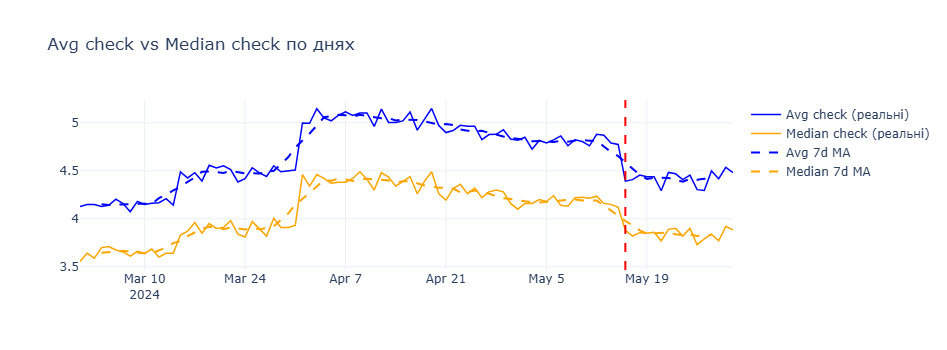

In [112]:
# Денна виручка
daily_rev = p_ok.groupby('date')['amount_original'].sum().reset_index(name='revenue')

# Денні спроби та успіхи (з повного датасету)
daily_all = p.groupby('date').agg(
    total=('id_order','count'),
    success=('status', lambda x: (x=='success').sum())
).reset_index()
daily_all['conversion'] = daily_all['success'] / daily_all['total']

# Медіана чека по дню
daily_median = p_ok.groupby('date')['amount_original'].median().reset_index(name='median_check')

# Джойн
daily = daily_rev.merge(daily_all, on='date').sort_values('date')
daily = daily.merge(daily_median, on='date')

# Avg check для порівняння з медіаною
daily['avg_check'] = daily['revenue'] / daily['success']

print(daily[['date','revenue','conversion','avg_check','median_check']].tail(20).to_string())

# Графік avg vs median check
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['avg_check'],
    name='Avg check (реальні)', line=dict(color='blue', width=1.5)
))
fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['median_check'],
    name='Median check (реальні)', line=dict(color='orange', width=1.5)
))

# MA тільки на графіку, не зберігаємо в daily
fig.add_trace(go.Scatter(
    x=daily['date'],
    y=daily['avg_check'].rolling(7, center=True).mean(),
    name='Avg 7d MA', line=dict(color='blue', width=2, dash='dash')
))
fig.add_trace(go.Scatter(
    x=daily['date'],
    y=daily['median_check'].rolling(7, center=True).mean(),
    name='Median 7d MA', line=dict(color='orange', width=2, dash='dash')
))

fig.add_vline(x='2024-05-16', line_dash='dash', line_color='red', line_width=2)

fig.update_layout(
    title='Avg check vs Median check по днях',
    height=350,
    template='plotly_white'
)
fig.show()

In [113]:
# === ДУБЛІКАТИ ===
print("=== ДУБЛІКАТИ ===")
print(f"payments дублікати: {payments.duplicated().sum()}")
print(f"regs дублікати: {regs.duplicated().sum()}")
print(f"splits дублікати: {splits.duplicated().sum()}")

# Дублікати по ключових полях
print(f"payments дублі по id_order: {payments['id_order'].duplicated().sum()}")
print(f"regs дублі по id_user: {regs['id_user'].duplicated().sum()}")
print(f"splits дублі по id_user: {splits['id_user'].duplicated().sum()}")

# === ПРОПУСКИ ===
print("\n=== ПРОПУСКИ ===")
print("payments:\n", payments.isnull().sum())
print("\nregs:\n", regs.isnull().sum())
print("\nsplits:\n", splits.isnull().sum())

# === ПІСЛЯ ДЖОЙНУ ===
print("\n=== ПРОПУСКИ ПІСЛЯ ДЖОЙНУ ===")
print(p[['gender','traffic_type','country_group','age_group','split_group']].isnull().sum())

# === АНОМАЛІЇ ===
print("\n=== АНОМАЛІЇ ===")
print(f"Від'ємні суми транзакцій: {(payments['amount_original'] < 0).sum()}")
print(f"Нульові суми транзакцій: {(payments['amount_original'] == 0).sum()}")
print(f"Мін/макс суми: {payments['amount_original'].min():.2f} / {payments['amount_original'].max():.2f}")
print(f"\nДіапазон дат: {payments['date'].min()} → {payments['date'].max()}")
print(f"Пропуски в датах: {payments['date'].isnull().sum()}")

=== ДУБЛІКАТИ ===
payments дублікати: 0
regs дублікати: 0
splits дублікати: 0
payments дублі по id_order: 0
regs дублі по id_user: 0
splits дублі по id_user: 0

=== ПРОПУСКИ ===
payments:
 id_order           0
id_user            0
date_created       0
amount_original    0
status             0
card_brand         0
os_version         0
date               0
dtype: int64

regs:
 id_user               0
date_created          0
cost             122155
traffic_type          0
gender                3
age_group             3
country_group         3
os_version            0
dtype: int64

splits:
 id_user        0
split_group    0
assigned_at    0
dtype: int64

=== ПРОПУСКИ ПІСЛЯ ДЖОЙНУ ===
gender           2
traffic_type     0
country_group    2
age_group        2
split_group      0
dtype: int64

=== АНОМАЛІЇ ===
Від'ємні суми транзакцій: 0
Нульові суми транзакцій: 98599
Мін/макс суми: 0.00 / 44.89

Діапазон дат: 2024-03-01 00:00:00 → 2024-05-31 00:00:00
Пропуски в датах: 0


In [114]:
print(regs[regs['cost'].isnull()]['traffic_type'].value_counts())

traffic_type
cpa        76303
organic    44228
ppc         1624
Name: count, dtype: int64


In [115]:
print(payments.groupby('status')['amount_original'].agg(['min','max','mean']))

          min    max      mean
status                        
fail     0.00   0.00  0.000000
success  0.82  44.89  4.647624


**Додаткова перевірка — gap між першим платежем і reg_date:**

- Gap розподілений від -91 до +91 днів, медіана = -6 днів
- 56% юзерів мають перший платіж ДО reg_date
- Висновок: `date_created` в registrations — імовірно дата оновлення
  профілю або синхронізації, а не реєстрації
- Для нашого аналізу це не критично — використовуємо regs
  тільки як таблицю статичних атрибутів юзера

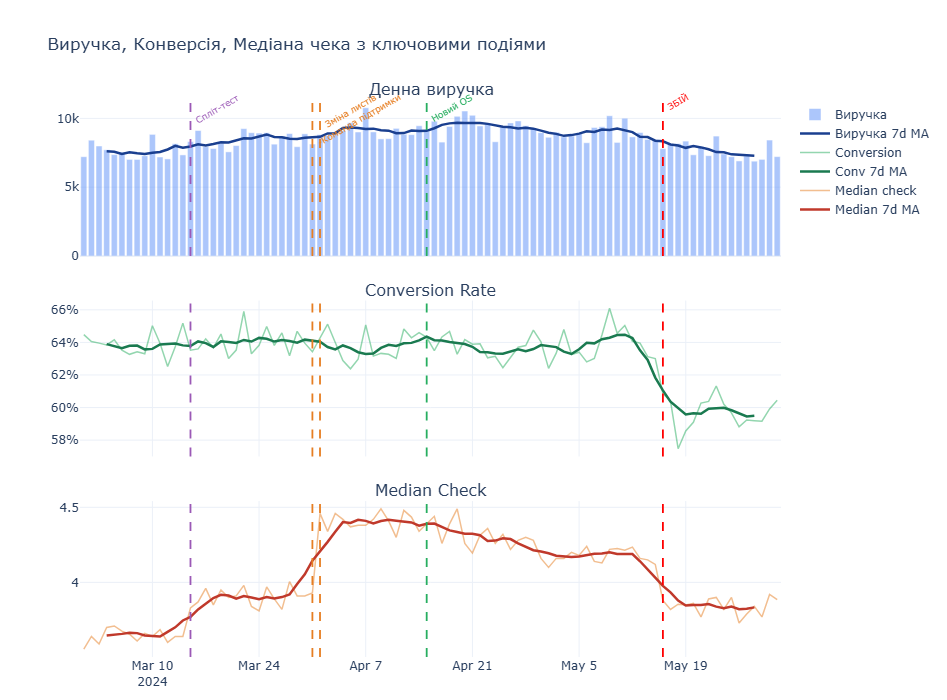

In [145]:
events = [
    ('2024-03-15', 'Спліт-тест',          '#9B59B6'),
    ('2024-03-31', '-Команда підтримки',   '#E67E22'),
    ('2024-04-01', 'Зміна листів',         '#E67E22'),
    ('2024-04-15', 'Новий OS',             '#27AE60'),
    ('2024-05-16', 'ЗБІЙ',                 'red'),
]

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=['Денна виручка', 'Conversion Rate', 'Median Check'],
    vertical_spacing=0.08,
    shared_xaxes=True
)

# Виручка
fig.add_trace(go.Bar(
    x=daily['date'], y=daily['revenue'],
    name='Виручка', marker_color='#5B8FF9', opacity=0.5
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=daily['date'],
    y=daily['revenue'].rolling(7, center=True).mean(),
    name='Виручка 7d MA', line=dict(color='#1a3f8f', width=2.5)
), row=1, col=1)

# Conversion
fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['conversion'],
    name='Conversion', line=dict(color='#27AE60', width=1.5), opacity=0.5
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=daily['date'],
    y=daily['conversion'].rolling(7, center=True).mean(),
    name='Conv 7d MA', line=dict(color='#1a7a50', width=2.5)
), row=2, col=1)

# Median check
fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['median_check'],
    name='Median check', line=dict(color='#E67E22', width=1.5), opacity=0.5
), row=3, col=1)
fig.add_trace(go.Scatter(
    x=daily['date'],
    y=daily['median_check'].rolling(7, center=True).mean(),
    name='Median 7d MA', line=dict(color='#c0392b', width=2.5)
), row=3, col=1)

# Події
for date, label, color in events:
    fig.add_vline(x=date, line_dash='dash', line_color=color, line_width=1.8)
    fig.add_annotation(
        x=date, y=1.02, xref='x', yref='paper',
        text=label, showarrow=False,
        font=dict(size=9, color=color),
        textangle=-30, xanchor='left'
    )

fig.update_yaxes(tickformat='.0%', row=2, col=1)
fig.update_layout(
    height=700,
    title='Виручка, Конверсія, Медіана чека з ключовими подіями',
    template='plotly_white',
    margin=dict(t=100, b=40)
)
fig.show()

## Крок 3.5 — Перевірка якості даних

**Що перевіряли:** дублікати, пропуски, аномалії.

**Результати:**

| Проблема | Деталь | Рішення ф
|---|---|---|
| Дублікати | 0 у всіх таблицях | ✅ Нічого не робимо |
| `cost` — 122k пропусків (40%) | CPA=76k, organic=44k, PPC=1.6k | ❌ Виключаємо з моделі |
| `gender/age/country` — 2-3 пропуски після джойну | Мізерна кількість | ✅ Залишаємо як є |
| Нульові суми — 98,599 | Рівно всі `fail` транзакції | ✅ Норма |
| Від'ємні суми | 0 | ✅ Аномалій немає |

**Висновок:** дані чисті. `cost` не використовуємо як фічу — 40% пропусків.

In [116]:
# Частка кожного сегменту у виручці по днях
def daily_share(df, col):
    grp = df.groupby(['date', col])['amount_original'].sum().reset_index()
    total = df.groupby('date')['amount_original'].sum().reset_index(name='total')
    grp = grp.merge(total, on='date')
    grp['share'] = grp['amount_original'] / grp['total']
    return grp

gender_share   = daily_share(p_ok, 'gender')
traffic_share  = daily_share(p_ok, 'traffic_type')
country_share  = daily_share(p_ok, 'country_group')
age_share      = daily_share(p_ok, 'age_group')
split_share    = daily_share(p_ok, 'split_group')
os_share       = daily_share(p_ok, 'os_version_reg')

print("gender_share shape:", gender_share.shape)
print(gender_share.head(10))

gender_share shape: (184, 5)
        date  gender  amount_original    total     share
0 2024-03-01  female          3637.46  7214.45  0.504191
1 2024-03-01    male          3576.99  7214.45  0.495809
2 2024-03-02  female          4191.14  8413.74  0.498130
3 2024-03-02    male          4222.60  8413.74  0.501870
4 2024-03-03  female          4087.13  7993.41  0.511312
5 2024-03-03    male          3906.28  7993.41  0.488688
6 2024-03-04  female          3823.27  7717.92  0.495376
7 2024-03-04    male          3894.65  7717.92  0.504624
8 2024-03-05  female          3720.47  7366.67  0.505041
9 2024-03-05    male          3646.20  7366.67  0.494959


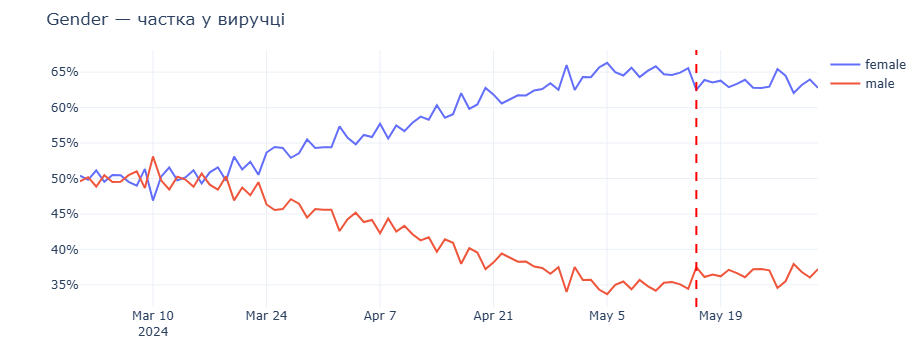

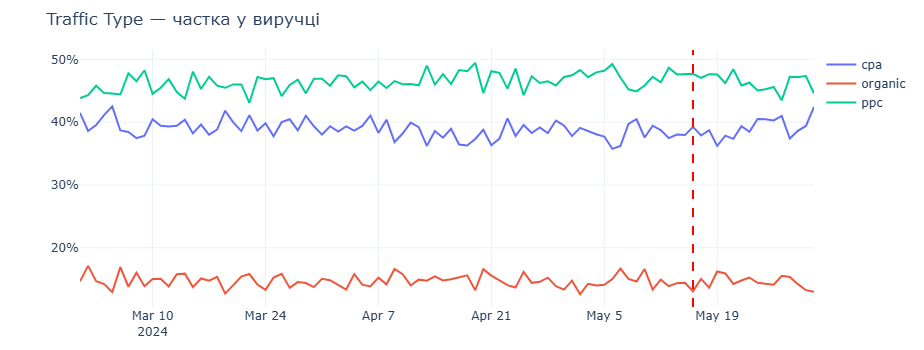

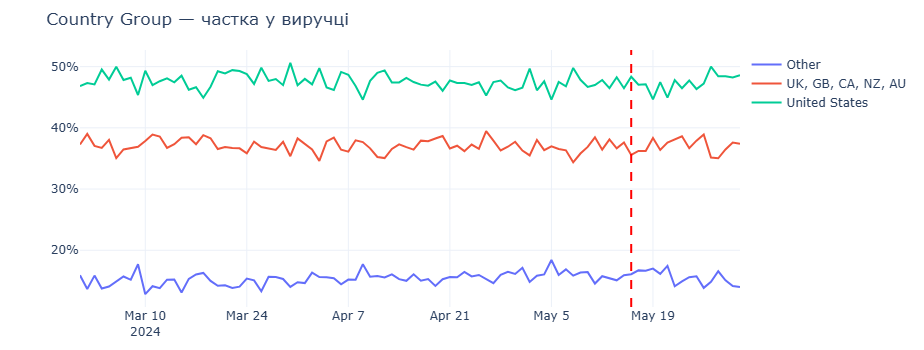

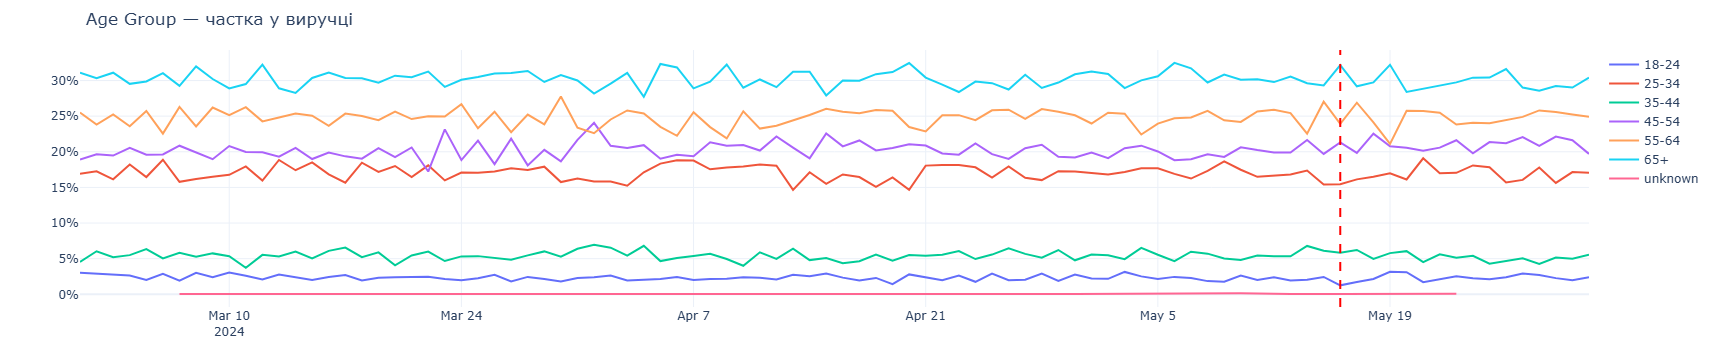

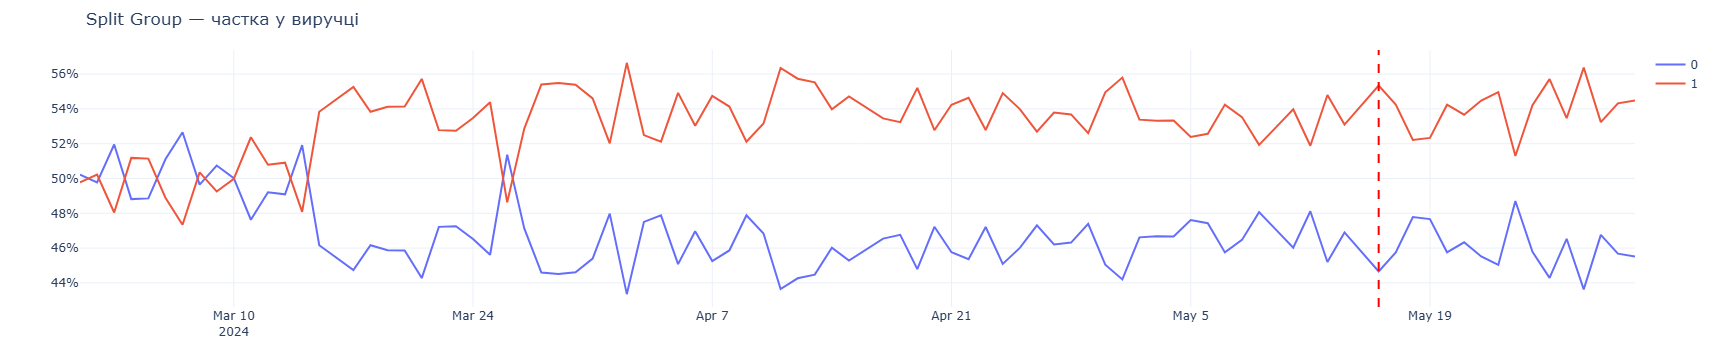

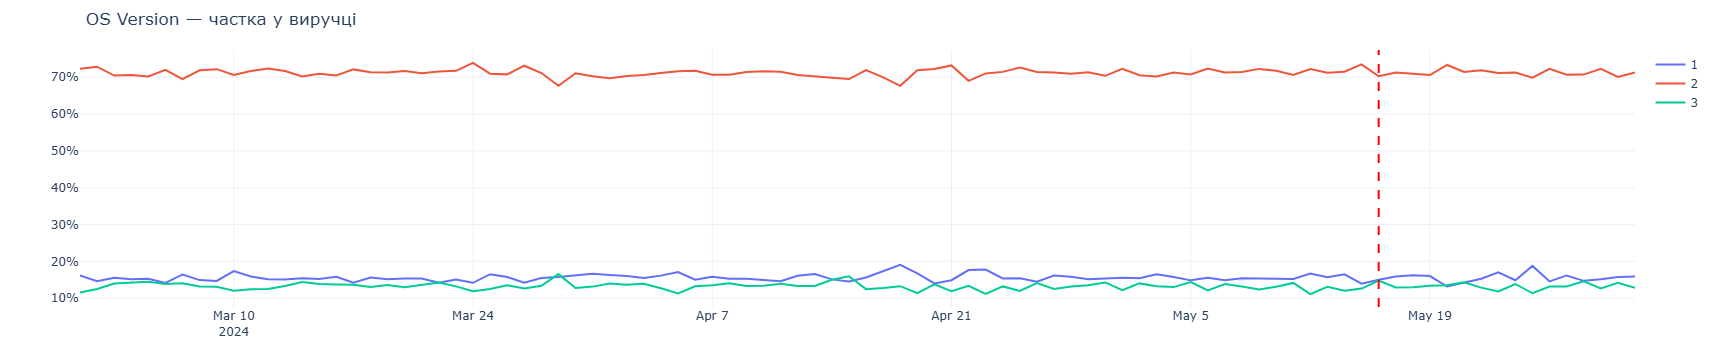

In [117]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Gender', 'Traffic Type',
        'Country Group', 'Age Group',
        'Split Group', 'OS Version'
    ],
    vertical_spacing=0.10,
    horizontal_spacing=0.08
)

OUTAGE = '2024-05-16'

datasets = [
    (gender_share,  'gender',         'Gender — частка у виручці'),
    (traffic_share, 'traffic_type',   'Traffic Type — частка у виручці'),
    (country_share, 'country_group',  'Country Group — частка у виручці'),
    (age_share,     'age_group',      'Age Group — частка у виручці'),
    (split_share,   'split_group',    'Split Group — частка у виручці'),
    (os_share,      'os_version_reg', 'OS Version — частка у виручці'),
]

for df, col, title in datasets:
    fig = go.Figure()

    for cat in sorted(df[col].unique()):
        sub = df[df[col] == cat].sort_values('date')
        fig.add_trace(go.Scatter(
            x=sub['date'], y=sub['share'],
            name=str(cat),
            mode='lines',
            line=dict(width=2),
            hovertemplate=f"{cat}<br>%{{x|%d %b}}<br>%{{y:.1%}}<extra></extra>"
        ))

    fig.add_vline(x=OUTAGE, line_dash='dash', line_color='red', line_width=2)

    fig.update_layout(
        title=title,
        height=350,
        template='plotly_white',
        yaxis_tickformat='.0%',
        margin=dict(t=50, b=30),
        legend=dict(orientation='v', x=1.01, y=1)
    )

    fig.show()

Рядків з cost: 177845 з 300000
По traffic_type:
traffic_type
ppc    136108
cpa     41737
Name: count, dtype: int64


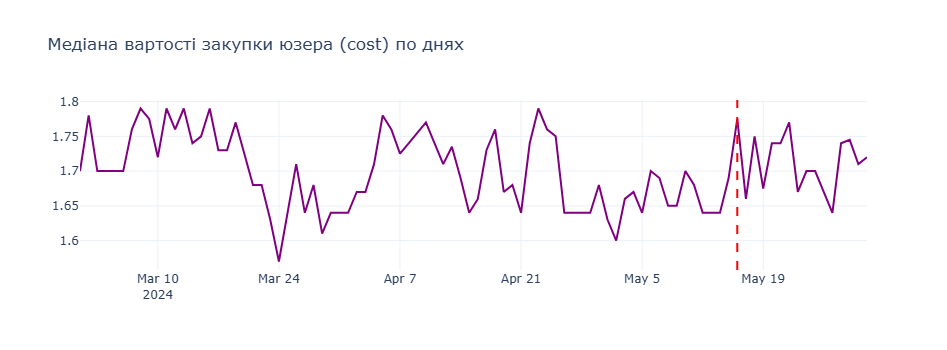

In [144]:
# Дивимось на cost — де є дані
regs['date_created'] = pd.to_datetime(regs['date_created'], utc=True).dt.date
regs['date_created'] = pd.to_datetime(regs['date_created'])

cost_daily = regs.dropna(subset=['cost']).groupby('date_created')['cost'].median().reset_index()
cost_daily.columns = ['date', 'median_cost']

print(f"Рядків з cost: {regs['cost'].notna().sum()} з {len(regs)}")
print(f"По traffic_type:\n{regs[regs['cost'].notna()]['traffic_type'].value_counts()}")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cost_daily['date'], y=cost_daily['median_cost'],
    name='Median cost', line=dict(color='purple', width=2)
))
fig.add_vline(x='2024-05-16', line_dash='dash', line_color='red', line_width=2)
fig.update_layout(
    title='Медіана вартості закупки юзера (cost) по днях',
    height=350,
    template='plotly_white'
)
fig.show()


## Крок 3.6 — Перевірка логічної консистентності даних

**Що перевіряємо:**
- Чи є платежі раніше дати реєстрації юзера
- Чи є платежі від юзерів яких немає в registrations
- Чи є юзери в payments яких немає в splits
- Чи є юзери зареєстровані після кінця періоду аналізу
- Чи коректний діапазон дат у кожній таблиці
- Чи є юзери з підозріло великою кількістю транзакцій за день
- Чи є однакові транзакції в один день від одного юзера (дублі по суті)
- Чи assigned_at у splits збігається з очікуваною датою старту тесту

In [119]:
# Підготовка дат реєстрації
regs['reg_date'] = pd.to_datetime(regs['date_created'], utc=True).dt.normalize()

# Джойн з датою реєстрації
p_check = payments.merge(
    regs[['id_user','reg_date']],
    on='id_user', how='left'
)

# Обидві дати без timezone для порівняння
p_check['date'] = pd.to_datetime(payments['date']).dt.tz_localize(None)
p_check['reg_date'] = p_check['reg_date'].dt.tz_localize(None)

# === 1. Платежі раніше реєстрації ===
early = p_check[p_check['date'] < p_check['reg_date']]
print(f"=== 1. Платежі раніше реєстрації ===")
print(f"Кількість: {len(early)}")
if len(early) > 0:
    print(early[['id_user','date','reg_date','status','amount_original']].head(10))

# === 2. Юзери в payments без реєстрації ===
no_reg = payments[~payments['id_user'].isin(regs['id_user'])]
print(f"\n=== 2. Юзери в payments без реєстрації ===")
print(f"Кількість транзакцій: {len(no_reg)}")
print(f"Унікальних юзерів: {no_reg['id_user'].nunique()}")

# === 3. Юзери в payments без запису в splits ===
no_split = payments[~payments['id_user'].isin(splits['id_user'])]
print(f"\n=== 3. Юзери в payments без splits ===")
print(f"Кількість транзакцій: {len(no_split)}")
print(f"Унікальних юзерів: {no_split['id_user'].nunique()}")

# === 4. Реєстрації після кінця аналізу ===
late_reg = regs[pd.to_datetime(regs['date_created'], utc=True).dt.tz_localize(None) > pd.Timestamp('2024-05-31')]
print(f"\n=== 4. Реєстрації після 31 травня ===")
print(f"Кількість: {len(late_reg)}")

# === 5. Діапазони дат ===
print(f"\n=== 5. Діапазони дат ===")
print(f"payments:      {payments['date'].min().date()} → {payments['date'].max().date()}")
print(f"registrations: {pd.to_datetime(regs['date_created'], utc=True).min().date()} → {pd.to_datetime(regs['date_created'], utc=True).max().date()}")
print(f"splits:        {splits['assigned_at'].min()} → {splits['assigned_at'].max()}")

# === 6. Юзери з >5 транзакцій за день ===
txn_per_day = payments.groupby(['id_user','date'])['id_order'].count().reset_index(name='txn_count')
suspicious = txn_per_day[txn_per_day['txn_count'] > 5]
print(f"\n=== 6. Юзери з >5 транзакцій за день ===")
print(f"Кількість випадків: {len(suspicious)}")
print(f"Розподіл кількості транзакцій на день:")
print(txn_per_day['txn_count'].value_counts().sort_index().head(10))

# === 7. Дублі — той самий юзер + дата + сума ===
dupes = payments[payments['status']=='success'].duplicated(
    subset=['id_user','date','amount_original'], keep=False
)
print(f"\n=== 7. Підозрілі дублі (юзер + дата + сума) ===")
print(f"Кількість: {dupes.sum()}")
if dupes.sum() > 0:
    print(payments[payments['status']=='success'][dupes][
        ['id_user','date','amount_original','card_brand']
    ].head(10))

# === 8. Splits assigned_at ===
splits['assigned_at'] = pd.to_datetime(splits['assigned_at'])
print(f"\n=== 8. Splits assigned_at розподіл ===")
print(splits['assigned_at'].value_counts().sort_index())
print(f"Всі юзери отримали split в один день: {splits['assigned_at'].nunique() == 1}")

=== 1. Платежі раніше реєстрації ===
Кількість: 136102
      id_user       date   reg_date   status  amount_original
0  1000135078 2024-03-01 2024-04-22  success             7.46
1  1000080782 2024-03-01 2024-03-29  success             3.82
2  1000019610 2024-03-01 2024-03-16  success             4.26
3  1000135310 2024-03-01 2024-05-26  success             6.37
4  1000229704 2024-03-01 2024-03-30  success             5.45
5  1000201407 2024-03-01 2024-04-04  success             4.82
6  1000144044 2024-03-01 2024-04-19  success             3.05
7  1000252300 2024-03-01 2024-03-08  success             2.29
8  1000194561 2024-03-01 2024-05-01  success             4.37
9  1000250294 2024-03-01 2024-04-10  success             2.87

=== 2. Юзери в payments без реєстрації ===
Кількість транзакцій: 0
Унікальних юзерів: 0

=== 3. Юзери в payments без splits ===
Кількість транзакцій: 0
Унікальних юзерів: 0

=== 4. Реєстрації після 31 травня ===
Кількість: 0

=== 5. Діапазони дат ===
payments:  

In [120]:
# Дата першого платежу по кожному юзеру
first_payment = payments[payments['status']=='success'].groupby('id_user')['date'].min().reset_index()
first_payment.columns = ['id_user','first_payment_date']

# Порівняємо з reg_date
check = first_payment.merge(regs[['id_user','reg_date']], on='id_user', how='left')
check['reg_date'] = pd.to_datetime(check['reg_date']).dt.tz_localize(None)
check['first_payment_date'] = pd.to_datetime(check['first_payment_date'])

check['gap_days'] = (check['first_payment_date'] - check['reg_date']).dt.days

print("=== Gap між першим платежем і reg_date ===")
print(check['gap_days'].describe())
print(f"\nПерший платіж ДО reg_date: {(check['gap_days'] < 0).sum()}")
print(f"Перший платіж В ДЕНЬ reg_date: {(check['gap_days'] == 0).sum()}")
print(f"Перший платіж ПІСЛЯ reg_date: {(check['gap_days'] > 0).sum()}")
print(f"\nРозподіл gap (днів):")
print(check['gap_days'].value_counts().sort_index().head(20))

=== Gap між першим платежем і reg_date ===
count    128370.000000
mean         -6.224640
std          37.158445
min         -91.000000
25%         -33.000000
50%          -6.000000
75%          20.000000
max          91.000000
Name: gap_days, dtype: float64

Перший платіж ДО reg_date: 72129
Перший платіж В ДЕНЬ reg_date: 1461
Перший платіж ПІСЛЯ reg_date: 54780

Розподіл gap (днів):
gap_days
-91     18
-90     48
-89     60
-88     84
-87    120
-86    123
-85    168
-84    149
-83    163
-82    207
-81    254
-80    232
-79    295
-78    319
-77    277
-76    311
-75    394
-74    360
-73    371
-72    386
Name: count, dtype: int64


## Гіпотези після аналізу структури атрибутів

### Що помітили на графіках (пункт 1):

**Гіпотеза 1 — Спліт-тест відштовхнув чоловіків**
Частка чоловіків починає падати рівно з 15 березня — дата старту спліт-тесту.
До цього gender був 50/50, після — жінки починають домінувати.
Можливо тестова зміна в продукті була менш релевантна для чоловіків.

**Гіпотеза 2 — Збій вдарив по конверсії, а не по попиту**
Кількість спроб оплати після 16 травня не впала — люди намагались платити.
Але конверсія впала з ~63.8% до ~59.7%.
Тобто збій зламав платіжний флоу технічно, а не відлякав юзерів.

**Гіпотеза 3 — Відтік чоловіків посилив ефект збою**
Чоловіки мають вищий ARPU ніж жінки.
Якщо після збою частка чоловіків ще більше впала —
це окремий структурний фактор втрати виручки поверх конверсії.

**Гіпотеза 4 — Cost закупки не змінився**
Графік median cost плоский до і після збою.
Структура закупки трафіку не змінилась — це не фактор дропу.
Cost виключаємо з моделі.

**Гіпотеза 5 — Новий OS і зміна листів не вплинули**
OS Version і Traffic Type стабільні весь період.
Жодного зсуву після відповідних подій не видно.

**Гіпотеза 6 — Спліт-тест валідний попри збій**
Тестова група (1) стабільно вище контрольної (0) весь період включно після збою.
Збій вплинув на обидві групи однаково — результати тесту не зіпсовані.

## Крок 6 — Візуалізація виручки з ключовими подіями

**Що робимо:**
Будуємо три графіки на одній часовій осі:
- Денна виручка (bar) + 7d MA (лінія)
- Conversion Rate по днях + 7d MA
- Median check по днях + 7d MA

На кожен графік наносимо вертикальні мітки всіх ключових подій:
- 15 березня — старт спліт-тесту
- 31 березня — скорочення команди підтримки
- 1 квітня — зміна логіки листів
- 15 квітня — реліз нового OS
- 16 травня — технічний збій 🔴

**Що шукаємо:**
- Чи є реакція метрик на кожну подію окремо
- Де починається стійкий тренд вниз — до збою чи після
- Чи виручка падала поступово (структурно) чи різко (технічно)
- Наскільки сильний розрив між трендом до збою і фактом після

**Що очікуємо побачити:**
Виручка зростала з березня по травень за рахунок спліт-тесту.
16 травня — різкий злам конверсії і median check.
Після збою виручка стабілізувалась на нижчому рівні і не відновлюється.

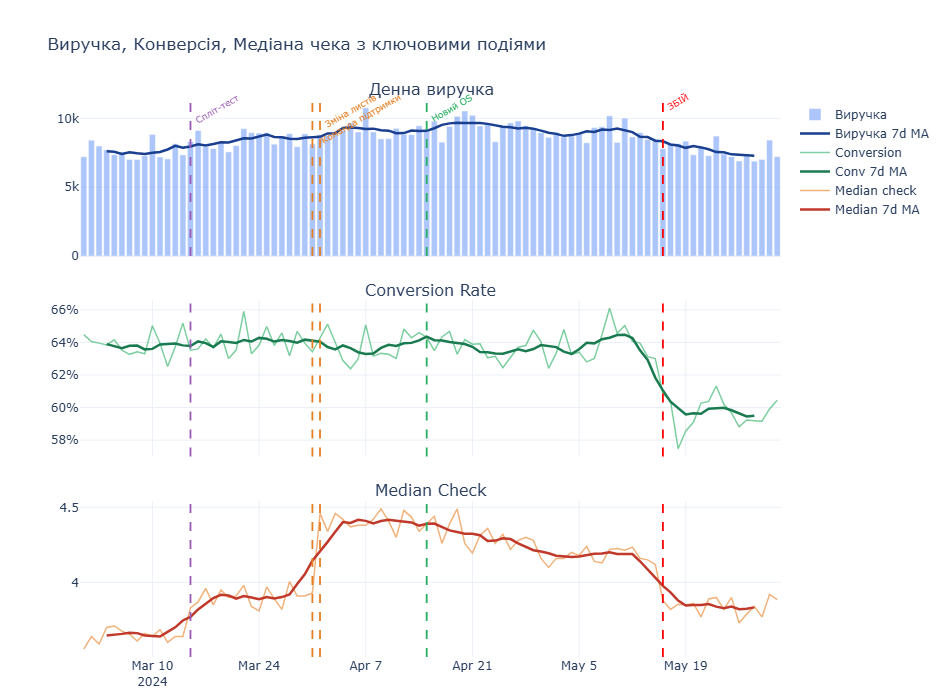

## Крок 7 — Кореляційний аналіз

**Що робимо:**
Рахуємо кореляцію кожного атрибута з виручкою на рівні транзакції
та на денному рівні (частка сегменту → денна виручка).

**Що очікуємо:**
- Split group — найсильніший сигнал (тест підіймає виручку)
- Gender — чоловіки платять більше за транзакцію
- Інші атрибути — слабкий або нульовий зв'язок

**Чому два рівні аналізу:**
- Рівень транзакції показує хто платить більше за раз
- Денний рівень показує як зміна структури юзерів впливає на загальну виручку

=== Кореляція з amount_original ===
      feature  correlation
0   is_split1     0.116494
1  gender_enc     0.002732
2     age_num     0.002063
3      os_enc     0.001129
4       is_us     0.000966
5      is_ppc     0.000722


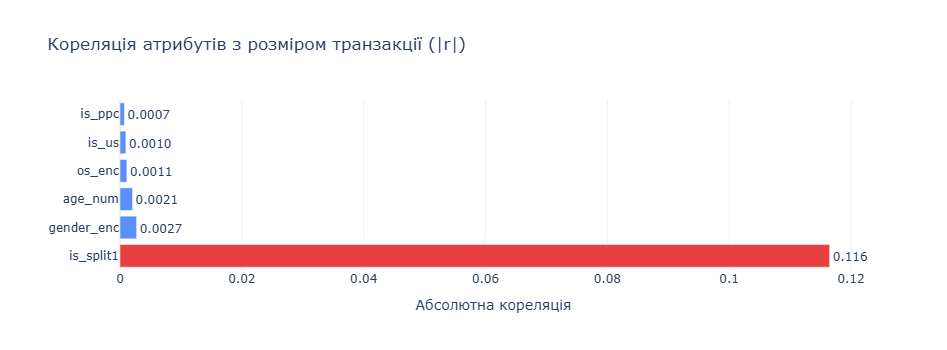

In [146]:
# Кореляція на рівні транзакції
p_ok['gender_enc']   = (p_ok['gender'] == 'male').astype(int)
p_ok['is_split1']    = (p_ok['split_group'] == '1').astype(int)
p_ok['is_ppc']       = (p_ok['traffic_type'] == 'ppc').astype(int)
p_ok['is_us']        = (p_ok['country_group'] == 'United States').astype(int)
p_ok['os_enc']       = p_ok['os_version_reg'].astype(int)

age_map = {'18-24':21,'25-34':29,'35-44':39,'45-54':49,'55-64':59,'65+':70,'unknown':45}
p_ok['age_num'] = p_ok['age_group'].map(age_map)

features = ['gender_enc','is_split1','is_ppc','is_us','os_enc','age_num']

corr = p_ok[features + ['amount_original']].corr()['amount_original'].drop('amount_original')
corr_df = corr.abs().sort_values(ascending=False).reset_index()
corr_df.columns = ['feature','correlation']
print("=== Кореляція з amount_original ===")
print(corr_df.to_string())

# Візуалізація
fig = go.Figure(go.Bar(
    x=corr_df['correlation'],
    y=corr_df['feature'],
    orientation='h',
    marker_color=['#E84040' if c > 0.05 else '#5B8FF9' for c in corr_df['correlation']],
    text=[f"{c:.4f}" for c in corr_df['correlation']],
    textposition='outside'
))

fig.update_layout(
    title='Кореляція атрибутів з розміром транзакції (|r|)',
    height=350,
    template='plotly_white',
    xaxis_title='Абсолютна кореляція',
    margin=dict(l=120)
)
fig.show()

In [123]:
# ARPU по гендеру
arpu = p_ok.groupby(['id_user','gender'])['amount_original'].sum().reset_index()
print(arpu.groupby('gender')['amount_original'].agg(['median','mean','count']))

        median      mean  count
gender                         
female    5.14  6.336632  72410
male      4.74  5.825561  55958


In [124]:
arpu_split = p_ok.groupby(['id_user','split_group'])['amount_original'].sum().reset_index()
print(arpu_split.groupby('split_group')['amount_original'].agg(['median','mean','count']))

             median      mean  count
split_group                         
0              4.65  5.720397  64038
1              5.29  6.505434  64332


   gender split_group  median_arpu  mean_arpu  users
0  female           0         4.81   5.913267  36114
1  female           1         5.49   6.757873  36296
2    male           0         4.47   5.471049  27923
3    male           1         5.04   6.178656  28035


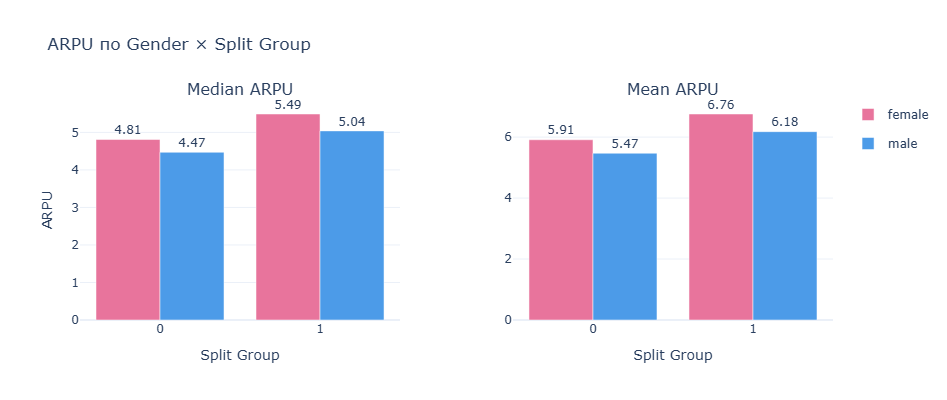

In [147]:
# ARPU по gender × split_group
arpu_full = p_ok.groupby(['id_user','gender','split_group'])['amount_original'].sum().reset_index()
arpu_summary = arpu_full.groupby(['gender','split_group'])['amount_original'].agg(['median','mean','count']).reset_index()
arpu_summary.columns = ['gender','split_group','median_arpu','mean_arpu','users']
print(arpu_summary.to_string())

# Графік — медіана ARPU по gender × split
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Median ARPU', 'Mean ARPU'],
    horizontal_spacing=0.15
)

colors = {'female': '#E8749C', 'male': '#4C9BE8'}

for gender in ['female','male']:
    sub = arpu_summary[arpu_summary['gender'] == gender]
    fig.add_trace(go.Bar(
        x=sub['split_group'],
        y=sub['median_arpu'],
        name=gender,
        marker_color=colors[gender],
        text=sub['median_arpu'].round(2),
        textposition='outside',
        legendgroup=gender
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=sub['split_group'],
        y=sub['mean_arpu'],
        name=gender,
        marker_color=colors[gender],
        text=sub['mean_arpu'].round(2),
        textposition='outside',
        showlegend=False,
        legendgroup=gender
    ), row=1, col=2)

fig.update_layout(
    title='ARPU по Gender × Split Group',
    height=400,
    template='plotly_white',
    barmode='group',
    xaxis_title='Split Group',
    xaxis2_title='Split Group',
    yaxis_title='ARPU',
)
fig.show()

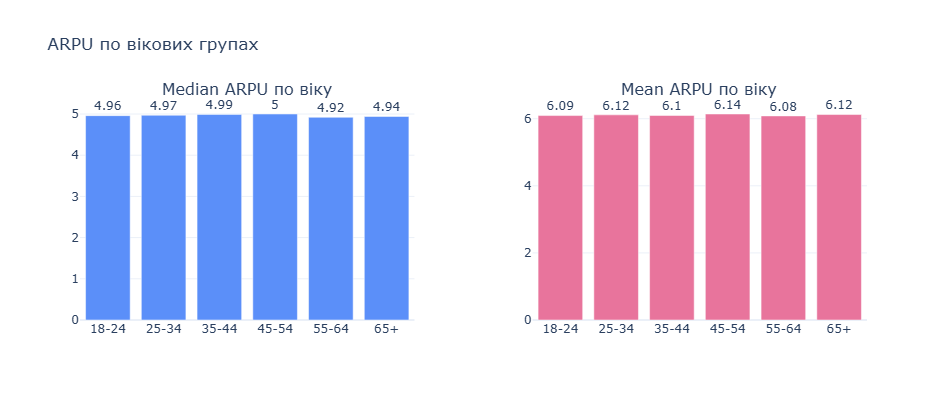

  age_group  median_arpu  mean_arpu  users
0     18-24         4.96   6.093880   2990
1     25-34         4.97   6.115491  21850
2     35-44         4.99   6.096375   6982
3     45-54         5.00   6.140717  25921
4     55-64         4.92   6.083494  31937
5       65+         4.94   6.124669  38674


In [148]:
# ARPU по age group
arpu_age = p_ok.groupby(['id_user','age_group'])['amount_original'].sum().reset_index()
arpu_age_summary = arpu_age.groupby('age_group')['amount_original'].agg(['median','mean','count']).reset_index()
arpu_age_summary.columns = ['age_group','median_arpu','mean_arpu','users']

# Сортуємо по віку
age_order = ['18-24','25-34','35-44','45-54','55-64','65+']
arpu_age_summary = arpu_age_summary[arpu_age_summary['age_group'].isin(age_order)]
arpu_age_summary['age_group'] = pd.Categorical(arpu_age_summary['age_group'], categories=age_order, ordered=True)
arpu_age_summary = arpu_age_summary.sort_values('age_group')

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Median ARPU по віку','Mean ARPU по віку'],
    horizontal_spacing=0.15)

fig.add_trace(go.Bar(
    x=arpu_age_summary['age_group'],
    y=arpu_age_summary['median_arpu'],
    marker_color='#5B8FF9',
    text=arpu_age_summary['median_arpu'].round(2),
    textposition='outside',
    name='Median ARPU'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=arpu_age_summary['age_group'],
    y=arpu_age_summary['mean_arpu'],
    marker_color='#E8749C',
    text=arpu_age_summary['mean_arpu'].round(2),
    textposition='outside',
    name='Mean ARPU'
), row=1, col=2)

fig.update_layout(
    title='ARPU по вікових групах',
    height=400,
    template='plotly_white',
    showlegend=False
)
fig.show()

print(arpu_age_summary.to_string())

In [150]:
from scipy import stats

# T-test ARPU між split групами окремо по гендеру
for gender in ['female','male']:
    group0 = arpu_full[(arpu_full['gender']==gender) & (arpu_full['split_group']=='0')]['amount_original']
    group1 = arpu_full[(arpu_full['gender']==gender) & (arpu_full['split_group']=='1')]['amount_original']
    
    t_stat, p_val = stats.ttest_ind(group0, group1)
    print(f"{gender}: group0 median={group0.median():.2f}, group1 median={group1.median():.2f}, p-value={p_val:.4f}")

# T-test загалом split 0 vs 1
g0 = arpu_full[arpu_full['split_group']=='0']['amount_original']
g1 = arpu_full[arpu_full['split_group']=='1']['amount_original']
t_stat, p_val = stats.ttest_ind(g0, g1)
print(f"\nЗагалом: p-value={p_val:.10f}")
print(f"Статистично значимо (p<0.05): {p_val < 0.05}")

female: group0 median=4.81, group1 median=5.49, p-value=0.0000
male: group0 median=4.47, group1 median=5.04, p-value=0.0000

Загалом: p-value=0.0000000000
Статистично значимо (p<0.05): True


## Крок 4 — Модель предикту виручки (Counterfactual)

**Мета:**
Побудувати модель на даних ДО 16 травня, спрогнозувати
яка б була виручка після 16 травня без збою.
Різниця прогноз - факт = втрати від збою.

**Підхід:**
Працюємо на денному рівні агрегації (92 дні).
Таргет: денна виручка (revenue).

**Фічі моделі:**
- `t` — порядковий номер дня (тренд)
- `dow` — день тижня (сезонність)
- `share_male` — частка чоловіків у платежах за день
- `share_split1` — частка тестової групи за день
- `share_ppc` — частка ppc трафіку за день
- `share_us` — частка US юзерів за день
- `attempts` — кількість спроб оплати за день

**Чому не беремо conversion як фічу:**
Conversion сама є наслідком збою — якщо додати її в модель,
модель "знатиме" про збій і прогноз буде некоректним.

**Моделі:**
1. Linear Regression — простий інтерпретований базис
2. Gradient Boosting — складніша модель, краще вловлює нелінійності

**Метрики оцінки:**
- R² на train (до 16 травня)
- MAE на test (після 16 травня)
- Загальна різниця прогноз vs факт в USD

In [126]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

cutoff = pd.Timestamp('2024-05-16')

# === Будуємо денні фічі ===
daily_features = daily[['date','revenue','total']].copy()
daily_features.columns = ['date','revenue','attempts']

# Частка чоловіків
share_male = p_ok.groupby('date').apply(
    lambda x: (x['gender']=='male').mean()
).reset_index(name='share_male')
daily_features = daily_features.merge(share_male, on='date')

# Частка split group 1
share_split1 = p_ok.groupby('date').apply(
    lambda x: (x['split_group']=='1').mean()
).reset_index(name='share_split1')
daily_features = daily_features.merge(share_split1, on='date')

# Частка ppc
share_ppc = p_ok.groupby('date').apply(
    lambda x: (x['traffic_type']=='ppc').mean()
).reset_index(name='share_ppc')
daily_features = daily_features.merge(share_ppc, on='date')

# Частка US
share_us = p_ok.groupby('date').apply(
    lambda x: (x['country_group']=='United States').mean()
).reset_index(name='share_us')
daily_features = daily_features.merge(share_us, on='date')

# Часові фічі
daily_features['t']   = (daily_features['date'] - daily_features['date'].min()).dt.days
daily_features['dow'] = daily_features['date'].dt.dayofweek

print("Shape:", daily_features.shape)
print(daily_features.head(3))

Shape: (92, 9)
        date  revenue  attempts  share_male  share_split1  share_ppc  \
0 2024-03-01  7214.45      2711    0.504005      0.497140   0.442220   
1 2024-03-02  8413.74      3166    0.502959      0.504438   0.440335   
2 2024-03-03  7993.41      3013    0.494032      0.490400   0.464453   

   share_us  t  dow  
0  0.467963  0    4  
1  0.472387  1    5  
2  0.473793  2    6  


Train: 76 днів | Test: 16 днів

=== Linear Regression ===
R² train:  0.761
MAE test:  2075
Прогноз May16-31:     155,282
Факт May16-31:        122,089
Втрати (LR):           33,193

=== Gradient Boosting ===
R² train:  0.999
MAE test:  1281
Прогноз May16-31:     142,584
Факт May16-31:        122,089
Втрати (GBM):          20,496


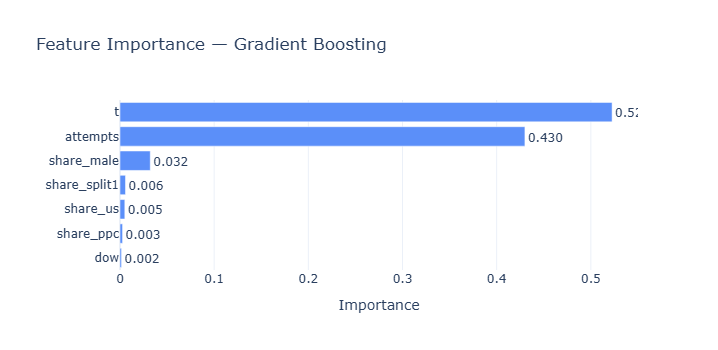

In [127]:
# === Train / Test split ===
train = daily_features[daily_features['date'] < cutoff].copy()
test  = daily_features[daily_features['date'] >= cutoff].copy()

feature_cols = ['t','dow','share_male','share_split1','share_ppc','share_us','attempts']

X_train = train[feature_cols]
y_train = train['revenue']
X_test  = test[feature_cols]
y_test  = test['revenue']

print(f"Train: {len(train)} днів | Test: {len(test)} днів")

# === Модель 1: Linear Regression ===
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_test_pred  = lr.predict(X_test)

print(f"\n=== Linear Regression ===")
print(f"R² train:  {r2_score(y_train, lr_train_pred):.3f}")
print(f"MAE test:  {mean_absolute_error(y_test, lr_test_pred):.0f}")
print(f"Прогноз May16-31:  {lr_test_pred.sum():>10,.0f}")
print(f"Факт May16-31:     {y_test.sum():>10,.0f}")
print(f"Втрати (LR):       {lr_test_pred.sum() - y_test.sum():>10,.0f}")

# === Модель 2: Gradient Boosting ===
gbm = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
gbm.fit(X_train, y_train)

gbm_train_pred = gbm.predict(X_train)
gbm_test_pred  = gbm.predict(X_test)

print(f"\n=== Gradient Boosting ===")
print(f"R² train:  {r2_score(y_train, gbm_train_pred):.3f}")
print(f"MAE test:  {mean_absolute_error(y_test, gbm_test_pred):.0f}")
print(f"Прогноз May16-31:  {gbm_test_pred.sum():>10,.0f}")
print(f"Факт May16-31:     {y_test.sum():>10,.0f}")
print(f"Втрати (GBM):      {gbm_test_pred.sum() - y_test.sum():>10,.0f}")

# === Feature importance GBM ===
feat_imp = pd.Series(gbm.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=True)

fig = go.Figure(go.Bar(
    x=feat_imp.values,
    y=feat_imp.index,
    orientation='h',
    marker_color='#5B8FF9',
    text=[f"{v:.3f}" for v in feat_imp.values],
    textposition='outside'
))
fig.update_layout(
    title='Feature Importance — Gradient Boosting',
    height=350,
    template='plotly_white',
    xaxis_title='Importance',
    margin=dict(l=120)
)
fig.show()

In [128]:
from sklearn.model_selection import cross_val_score

configs = [
    {'n_estimators': 20,  'max_depth': 2, 'learning_rate': 0.2,  'subsample': 1.0},
    {'n_estimators': 30,  'max_depth': 2, 'learning_rate': 0.1,  'subsample': 1.0},
    {'n_estimators': 50,  'max_depth': 2, 'learning_rate': 0.1,  'subsample': 1.0},
    {'n_estimators': 50,  'max_depth': 2, 'learning_rate': 0.05, 'subsample': 1.0},
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 1.0},
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 1.0},
    {'n_estimators': 50,  'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0},
    {'n_estimators': 50,  'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 50,  'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.6},
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.6},
    {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.8},
    {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.6},
    {'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.6},
    {'n_estimators': 50,  'max_depth': 2, 'learning_rate': 0.1,  'subsample': 0.8},
    {'n_estimators': 30,  'max_depth': 2, 'learning_rate': 0.1,  'subsample': 0.8},
    {'n_estimators': 30,  'max_depth': 2, 'learning_rate': 0.2,  'subsample': 0.8},
    {'n_estimators': 20,  'max_depth': 2, 'learning_rate': 0.2,  'subsample': 0.8},
    {'n_estimators': 20,  'max_depth': 2, 'learning_rate': 0.3,  'subsample': 0.8},
]

print("=== Підбір параметрів GBM (5-fold CV на train) ===")
print(f"{'n_est':>6} {'depth':>6} {'lr':>6} {'subs':>6} | {'CV R²':>8} {'std':>8} | {'train R²':>9}")

results = []
for cfg in configs:
    model = GradientBoostingRegressor(**cfg, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    results.append({
        **cfg,
        'cv_r2': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_r2': train_r2
    })
    print(f"{cfg['n_estimators']:>6} {cfg['max_depth']:>6} {cfg['learning_rate']:>6} {cfg['subsample']:>6} | "
          f"{cv_scores.mean():>8.3f} {cv_scores.std():>8.3f} | {train_r2:>9.3f}")

# Найкращий по CV R²
best = max(results, key=lambda x: x['cv_r2'])
print(f"\n=== Найкращий конфіг ===")
print(best)

=== Підбір параметрів GBM (5-fold CV на train) ===
 n_est  depth     lr   subs |    CV R²      std |  train R²
    20      2    0.2    1.0 |   -0.007    0.574 |     0.973
    30      2    0.1    1.0 |   -0.063    0.570 |     0.952
    50      2    0.1    1.0 |    0.007    0.612 |     0.982
    50      2   0.05    1.0 |   -0.044    0.526 |     0.936
   100      2   0.05    1.0 |    0.040    0.562 |     0.982
   100      2   0.01    1.0 |   -0.389    0.673 |     0.747
    50      3   0.05    1.0 |   -0.048    0.582 |     0.975
    50      2   0.05    0.8 |   -0.007    0.542 |     0.933
    50      2   0.05    0.6 |    0.021    0.517 |     0.932
   100      2   0.05    0.8 |    0.078    0.552 |     0.980
   100      3   0.05    0.8 |    0.054    0.569 |     0.995
   100      2   0.05    0.6 |    0.078    0.505 |     0.980
   200      2   0.01    0.8 |   -0.064    0.541 |     0.904
   200      2   0.01    0.6 |   -0.021    0.520 |     0.901
   300      2   0.01    0.6 |    0.034    0.489 |

=== Фінальна модель: Linear Regression ===
R² train:          0.761
MAE test:          2075
Прогноз May16-31:     155,282
Факт May16-31:        122,089
Втрати:                33,193
Втрати на день:         2,075

=== Коефіцієнти Linear Regression ===
        feature  coefficient
2    share_male  2510.793646
3  share_split1  1935.616373
5      share_us -1733.095553
4     share_ppc  -869.265194
0             t    26.580151
1           dow    -4.430846
6      attempts     2.882141


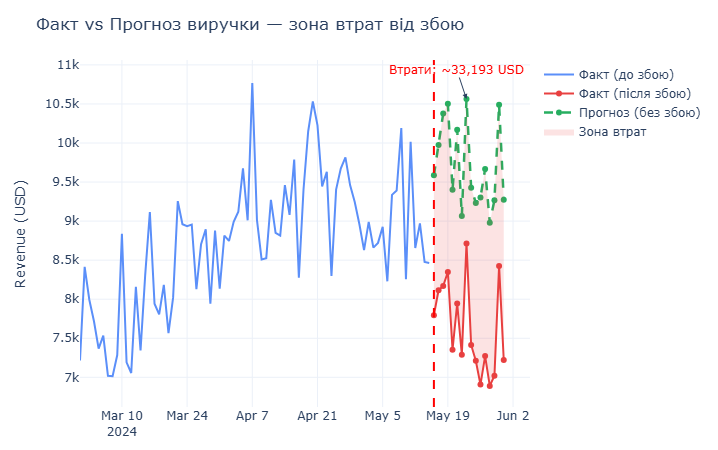

In [129]:
# Фінальна модель — Linear Regression
print("=== Фінальна модель: Linear Regression ===")
print(f"R² train:          {r2_score(y_train, lr_train_pred):.3f}")
print(f"MAE test:          {mean_absolute_error(y_test, lr_test_pred):.0f}")
print(f"Прогноз May16-31:  {lr_test_pred.sum():>10,.0f}")
print(f"Факт May16-31:     {y_test.sum():>10,.0f}")
print(f"Втрати:            {lr_test_pred.sum() - y_test.sum():>10,.0f}")
print(f"Втрати на день:    {(lr_test_pred.sum() - y_test.sum())/16:>10,.0f}")

# Коефіцієнти моделі
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print("\n=== Коефіцієнти Linear Regression ===")
print(coef_df.to_string())

# Графік факт vs прогноз
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train['date'], y=y_train,
    name='Факт (до збою)',
    line=dict(color='#5B8FF9', width=2)
))
fig.add_trace(go.Scatter(
    x=test['date'], y=y_test,
    name='Факт (після збою)',
    line=dict(color='#E84040', width=2)
))
fig.add_trace(go.Scatter(
    x=test['date'], y=lr_test_pred,
    name='Прогноз (без збою)',
    line=dict(color='#27AE60', width=2.5, dash='dash')
))

# Заливка зони втрат
fig.add_trace(go.Scatter(
    x=list(test['date']) + list(test['date'])[::-1],
    y=list(lr_test_pred) + list(y_test.values)[::-1],
    fill='toself',
    fillcolor='rgba(232, 64, 64, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Зона втрат'
))

fig.add_vline(x='2024-05-16', line_dash='dash', line_color='red', line_width=2)

loss_total = lr_test_pred.sum() - y_test.sum()
fig.add_annotation(
    x='2024-05-23',
    y=float(pd.Series(lr_test_pred).max()),
    text=f'Втрати: ~{loss_total:,.0f} USD',
    showarrow=True,
    arrowhead=2,
    font=dict(color='red', size=12)
)

fig.update_layout(
    title='Факт vs Прогноз виручки — зона втрат від збою',
    height=450,
    template='plotly_white',
    yaxis_title='Revenue (USD)',
    margin=dict(t=60, b=40)
)
fig.show()

In [130]:
# === Додаткові фічі ===

# Унікальні юзери за день
daily_users = p_ok.groupby('date')['id_user'].nunique().reset_index(name='unique_users')
daily_features = daily_features.merge(daily_users, on='date')

# Частка жінок
share_female = p_ok.groupby('date').apply(
    lambda x: (x['gender']=='female').mean()
).reset_index(name='share_female')
daily_features = daily_features.merge(share_female, on='date')

# Частка 65+
share_65 = p_ok.groupby('date').apply(
    lambda x: (x['age_group']=='65+').mean()
).reset_index(name='share_65plus')
daily_features = daily_features.merge(share_65, on='date')

# Fail rate за день (з повного датасету)
fail_rate = p.groupby('date').apply(
    lambda x: (x['status']=='fail').mean()
).reset_index(name='fail_rate')
daily_features = daily_features.merge(fail_rate, on='date')

# Події як бінарні фічі
daily_features['is_post_split']   = (daily_features['date'] >= '2024-03-15').astype(int)
daily_features['is_post_support'] = (daily_features['date'] >= '2024-03-31').astype(int)
daily_features['is_post_letters'] = (daily_features['date'] >= '2024-04-01').astype(int)
daily_features['is_post_os']      = (daily_features['date'] >= '2024-04-15').astype(int)

# Циклічність
daily_features['is_weekend']     = (daily_features['dow'] >= 5).astype(int)
daily_features['week_of_month']  = daily_features['date'].dt.day.apply(
    lambda d: (d - 1) // 7 + 1
)

print("Нові фічі додано. Shape:", daily_features.shape)
print(daily_features.columns.tolist())

# Перевіримо fail_rate до/після збою
cutoff = pd.Timestamp('2024-05-16')
pre_fail  = daily_features[daily_features['date'] < cutoff]['fail_rate'].mean()
post_fail = daily_features[daily_features['date'] >= cutoff]['fail_rate'].mean()
print(f"\nFail rate до збою:    {pre_fail:.4f}")
print(f"Fail rate після збою: {post_fail:.4f}")
print(f"Різниця:              {post_fail - pre_fail:.4f}")

Нові фічі додано. Shape: (92, 19)
['date', 'revenue', 'attempts', 'share_male', 'share_split1', 'share_ppc', 'share_us', 't', 'dow', 'unique_users', 'share_female', 'share_65plus', 'fail_rate', 'is_post_split', 'is_post_support', 'is_post_letters', 'is_post_os', 'is_weekend', 'week_of_month']

Fail rate до збою:    0.3615
Fail rate після збою: 0.4031
Різниця:              0.0416


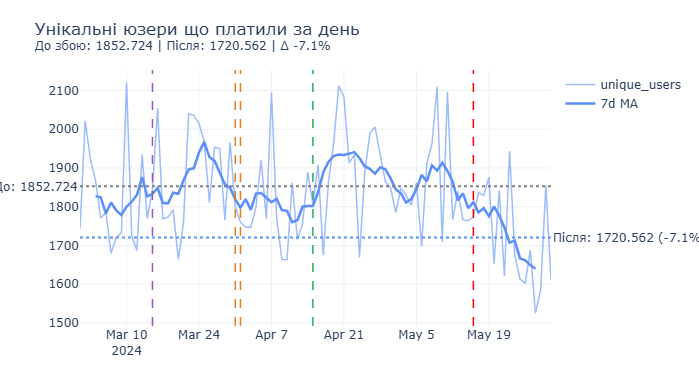

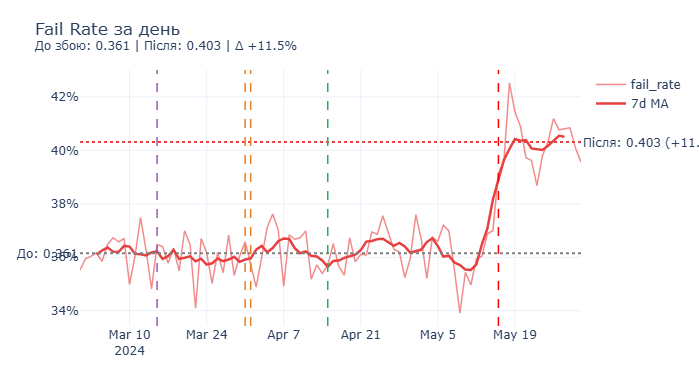

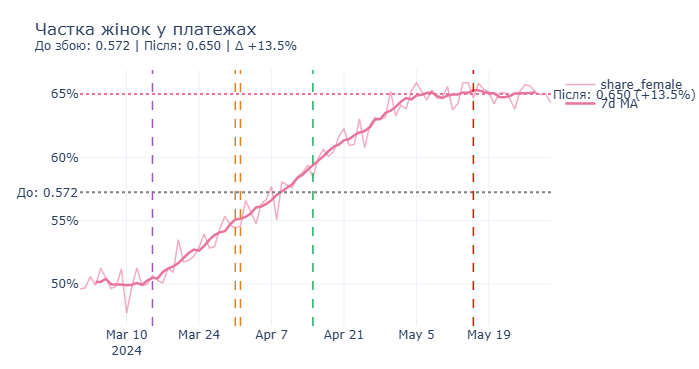

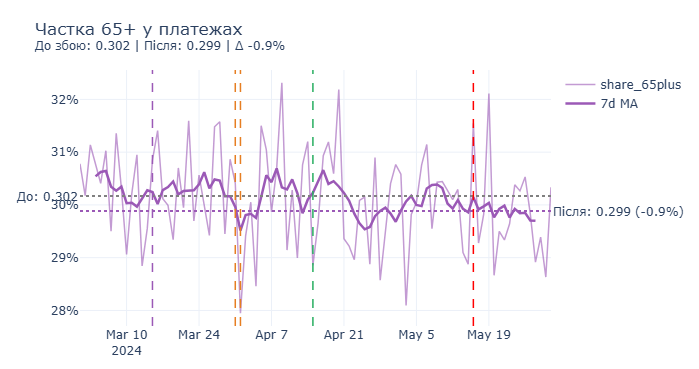


=== Зміна нових фічей до/після збою ===
Фіча                         До      Після      Δ абс      Δ %
--------------------------------------------------------------
unique_users           1852.724   1720.562   -132.161    -7.1%
fail_rate                 0.361      0.403      0.042    11.5%
share_female              0.572      0.650      0.077    13.5%
share_65plus              0.302      0.299     -0.003    -0.9%


In [131]:
# Графіки нових фічей по датах
new_features = [
    ('unique_users',  'Унікальні юзери що платили за день',  '#5B8FF9'),
    ('fail_rate',     'Fail Rate за день',                   '#E84040'),
    ('share_female',  'Частка жінок у платежах',             '#E8749C'),
    ('share_65plus',  'Частка 65+ у платежах',               '#9B59B6'),
]

for col, title, color in new_features:
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=daily_features['date'],
        y=daily_features[col],
        name=col,
        line=dict(color=color, width=1.5),
        opacity=0.6
    ))

    # 7d MA
    fig.add_trace(go.Scatter(
        x=daily_features['date'],
        y=daily_features[col].rolling(7, center=True).mean(),
        name='7d MA',
        line=dict(color=color, width=2.5)
    ))

    # Середні до/після
    pre_avg  = daily_features[daily_features['date'] < cutoff][col].mean()
    post_avg = daily_features[daily_features['date'] >= cutoff][col].mean()
    delta    = post_avg - pre_avg
    delta_pct = delta / pre_avg * 100

    fig.add_hline(y=pre_avg,  line_dash='dot', line_color='grey',
                  annotation_text=f'До: {pre_avg:.3f}',
                  annotation_position='left')
    fig.add_hline(y=post_avg, line_dash='dot', line_color=color,
                  annotation_text=f'Після: {post_avg:.3f} ({delta_pct:+.1f}%)',
                  annotation_position='right')

    # Події
    events = [
        ('2024-03-15', '#9B59B6'),
        ('2024-03-31', '#E67E22'),
        ('2024-04-01', '#E67E22'),
        ('2024-04-15', '#27AE60'),
        ('2024-05-16', 'red'),
    ]
    for date, ev_color in events:
        fig.add_vline(x=date, line_dash='dash',
                      line_color=ev_color, line_width=1.5)

    fig.update_layout(
        title=f'{title}<br><sup>До збою: {pre_avg:.3f} | Після: {post_avg:.3f} | Δ {delta_pct:+.1f}%</sup>',
        height=350,
        template='plotly_white',
        margin=dict(t=70, b=40),
        showlegend=True
    )

    if col in ['fail_rate', 'share_female', 'share_65plus']:
        fig.update_yaxes(tickformat='.0%')

    fig.show()

# Підсумкова таблиця змін
print("\n=== Зміна нових фічей до/після збою ===")
print(f"{'Фіча':<20} {'До':>10} {'Після':>10} {'Δ абс':>10} {'Δ %':>8}")
print("-" * 62)
for col, title, _ in new_features:
    pre  = daily_features[daily_features['date'] < cutoff][col].mean()
    post = daily_features[daily_features['date'] >= cutoff][col].mean()
    print(f"{col:<20} {pre:>10.3f} {post:>10.3f} {post-pre:>10.3f} {(post-pre)/pre*100:>7.1f}%")

In [132]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Базові фічі (стара модель)
feature_cols_base = [
    't', 'dow', 'share_male', 'share_split1',
    'share_ppc', 'share_us', 'attempts'
]

# Розширені фічі (нова модель)
# fail_rate НЕ включаємо — це наслідок збою
feature_cols_ext = [
    't', 'dow', 'is_weekend', 'week_of_month',
    'share_male', 'share_female', 'share_65plus',
    'share_split1', 'share_ppc', 'share_us',
    'attempts', 'unique_users',
    'is_post_split', 'is_post_support',
    'is_post_letters', 'is_post_os'
]

train = daily_features[daily_features['date'] < cutoff].copy()
test  = daily_features[daily_features['date'] >= cutoff].copy()

y_train = train['revenue']
y_test  = test['revenue']

# Масштабування для Ridge/Lasso
scaler = StandardScaler()

results = {}

for name, cols in [('LR Base', feature_cols_base), ('LR Extended', feature_cols_ext)]:
    model = LinearRegression()
    model.fit(train[cols], y_train)
    pred_train = model.predict(train[cols])
    pred_test  = model.predict(test[cols])
    results[name] = {
        'model': model,
        'cols': cols,
        'pred_test': pred_test,
        'r2_train': r2_score(y_train, pred_train),
        'mae_test': mean_absolute_error(y_test, pred_test),
        'pred_sum': pred_test.sum(),
        'loss': pred_test.sum() - y_test.sum()
    }

# Ridge (регуляризація L2)
for alpha in [0.1, 1.0, 10.0]:
    X_train_s = scaler.fit_transform(train[feature_cols_ext])
    X_test_s  = scaler.transform(test[feature_cols_ext])
    model = Ridge(alpha=alpha)
    model.fit(X_train_s, y_train)
    pred_train = model.predict(X_train_s)
    pred_test  = model.predict(X_test_s)
    name = f'Ridge a={alpha}'
    results[name] = {
        'model': model,
        'pred_test': pred_test,
        'r2_train': r2_score(y_train, pred_train),
        'mae_test': mean_absolute_error(y_test, pred_test),
        'pred_sum': pred_test.sum(),
        'loss': pred_test.sum() - y_test.sum()
    }

# Підсумок
print(f"{'Модель':<20} {'R² train':>9} {'MAE test':>9} {'Прогноз':>10} {'Втрати':>10}")
print("-" * 62)
for name, r in results.items():
    print(f"{name:<20} {r['r2_train']:>9.3f} {r['mae_test']:>9.0f} "
          f"{r['pred_sum']:>10,.0f} {r['loss']:>10,.0f}")

print(f"\nФакт May16-31: {y_test.sum():,.0f}")

Модель                R² train  MAE test    Прогноз     Втрати
--------------------------------------------------------------
LR Base                  0.761      2075    155,282     33,193
LR Extended              0.983       654    132,547     10,458
Ridge a=0.1              0.982       685    133,055     10,967
Ridge a=1.0              0.981       830    135,375     13,286
Ridge a=10.0             0.964      1114    139,909     17,821

Факт May16-31: 122,089


## Крок 4.1 — Розширена модель з додатковими факторами

**Нові фічі які додаємо:**

**З умови задачі:**
- `is_post_split` — після 15 березня (спліт активний)
- `is_post_support` — після 31 березня (менша команда підтримки)
- `is_post_letters` — після 1 квітня (нова логіка листів)
- `is_post_os` — після 15 квітня (новий OS)

**Циклічність:**
- `dow` — вже є (день тижня)
- `is_weekend` — вихідні окремо
- `week_of_month` — тиждень місяця (1-4)

**З даних:**
- `fail_rate` — частка failed транзакцій за день
  (зростає при збої — але обережно, це може бути наслідком)
- `unique_users` — кількість унікальних юзерів що платили
- `share_female` — частка жінок (вища = більше ARPU)
- `share_65plus` — частка 65+ (найбільша вікова група)

**Що НЕ додаємо:**
- `conversion` — наслідок збою, не причина
- `cost` — 40% пропусків

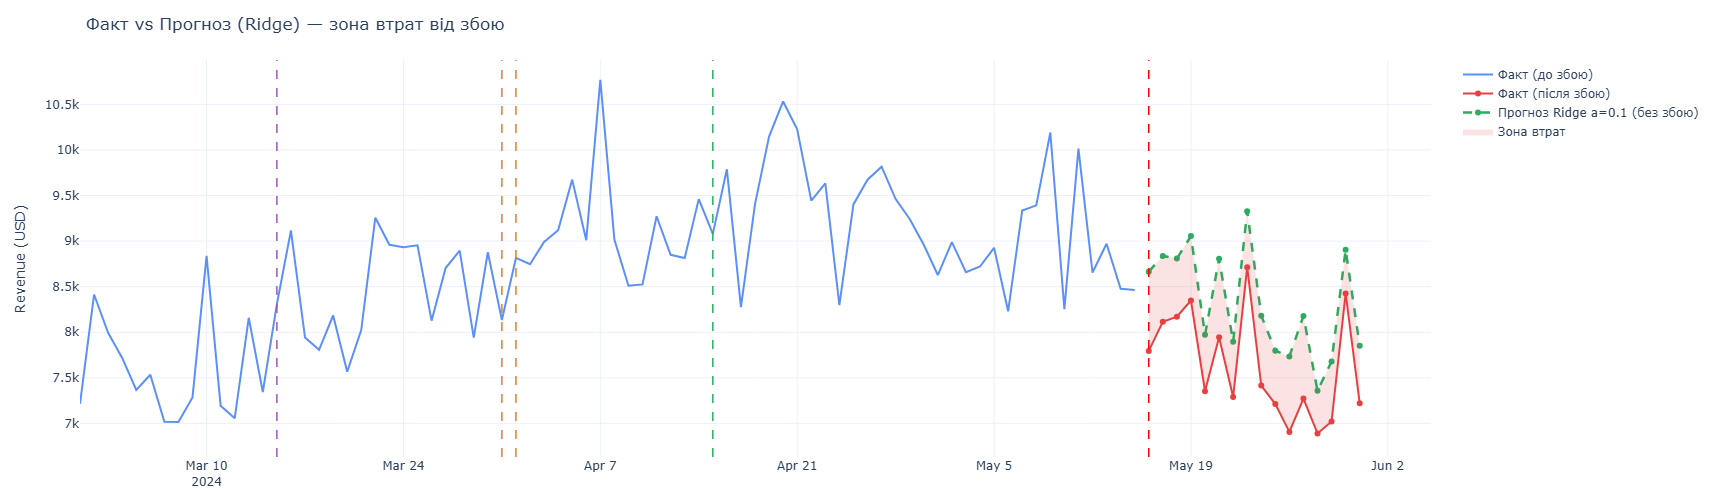


=== ФІНАЛЬНИЙ РЕЗУЛЬТАТ ===
Факт May16-31:        122,089 USD
Прогноз May16-31:     133,055 USD
Втрати від збою:       10,967 USD
Втрати на день:           685 USD/день


In [153]:
# Фінальна модель — Ridge a=0.1
scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(train[feature_cols_ext])
X_test_final  = scaler_final.transform(test[feature_cols_ext])

ridge_final = Ridge(alpha=0.1)
ridge_final.fit(X_train_final, y_train)
ridge_pred = ridge_final.predict(X_test_final)

loss_total = ridge_pred.sum() - y_test.sum()
loss_per_day = loss_total / 16

# Графік
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train['date'], y=y_train,
    name='Факт (до збою)',
    line=dict(color='#5B8FF9', width=2)
))
fig.add_trace(go.Scatter(
    x=test['date'], y=y_test,
    name='Факт (після збою)',
    line=dict(color='#E84040', width=2)
))
fig.add_trace(go.Scatter(
    x=test['date'], y=ridge_pred,
    name=f'Прогноз Ridge a=0.1 (без збою)',
    line=dict(color='#27AE60', width=2.5, dash='dash')
))

# Зона втрат
fig.add_trace(go.Scatter(
    x=list(test['date']) + list(test['date'])[::-1],
    y=list(ridge_pred) + list(y_test.values)[::-1],
    fill='toself',
    fillcolor='rgba(232, 64, 64, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Зона втрат'
))

# Події
events = [
    ('2024-03-15', 'Спліт'),
    ('2024-03-31', 'Підтримка'),
    ('2024-04-01', 'Листи'),
    ('2024-04-15', 'Новий OS'),
    ('2024-05-16', 'ЗБІЙ'),
]
colors_ev = ['#9B59B6','#E67E22','#E67E22','#27AE60','red']

for (date, label), color in zip(events, colors_ev):
    fig.add_vline(x=date, line_dash='dash', line_color=color, line_width=1.5)


fig.update_layout(
    title='Факт vs Прогноз (Ridge) — зона втрат від збою',
    height=500,
    template='plotly_white',
    yaxis_title='Revenue (USD)',
    margin=dict(t=60, b=40)
)
fig.show()

print(f"\n=== ФІНАЛЬНИЙ РЕЗУЛЬТАТ ===")
print(f"Факт May16-31:     {y_test.sum():>10,.0f} USD")
print(f"Прогноз May16-31:  {ridge_pred.sum():>10,.0f} USD")
print(f"Втрати від збою:   {loss_total:>10,.0f} USD")
print(f"Втрати на день:    {loss_per_day:>10,.0f} USD/день")

=== Сирі дані cost до/після збою ===
До збою:    missing_share=0.392, total_spend/day=4,538
Після збою: missing_share=0.468, total_spend/day=4,534

=== Останні 20 днів (сирі) ===
         date  total_regs  cost_filled  cost_missing  missing_share  total_spend
72 2024-05-12        3775         2174          1601       0.424106      4571.73
73 2024-05-13        3610         2055          1555       0.430748      4731.67
74 2024-05-14        3673         2064          1609       0.438062      4907.26
75 2024-05-15        3522         1950          1572       0.446337      4746.06
76 2024-05-16        3477         1908          1569       0.451251      4570.24
77 2024-05-17        3369         1784          1585       0.470466      4070.62
78 2024-05-18        3471         1923          1548       0.445981      4530.40
79 2024-05-19        3602         1984          1618       0.449195      5053.45
80 2024-05-20        3448         1827          1621       0.470128      4327.91
81 2024-05-

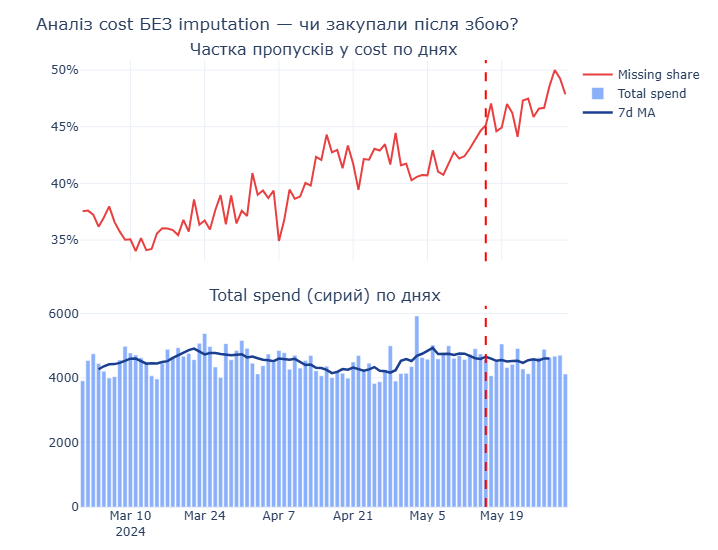

In [134]:
# Сирі дані cost БЕЗ imputation
regs['reg_date'] = pd.to_datetime(regs['date_created'], utc=True).dt.normalize().dt.tz_localize(None)

# Кількість реєстрацій і пропусків по днях
daily_cost_raw = regs.groupby('reg_date').agg(
    total_regs=('id_user','count'),
    cost_filled=('cost', lambda x: x.notna().sum()),
    cost_missing=('cost', lambda x: x.isna().sum()),
    median_cost=('cost','median'),
    total_spend=('cost','sum')
).reset_index()
daily_cost_raw.columns = ['date','total_regs','cost_filled','cost_missing','median_cost','total_spend']
daily_cost_raw['missing_share'] = daily_cost_raw['cost_missing'] / daily_cost_raw['total_regs']
daily_cost_raw['date'] = pd.to_datetime(daily_cost_raw['date'])

# До/після збою
pre  = daily_cost_raw[daily_cost_raw['date'] < cutoff]
post = daily_cost_raw[daily_cost_raw['date'] >= cutoff]

print("=== Сирі дані cost до/після збою ===")
print(f"До збою:    missing_share={pre['missing_share'].mean():.3f}, total_spend/day={pre['total_spend'].mean():,.0f}")
print(f"Після збою: missing_share={post['missing_share'].mean():.3f}, total_spend/day={post['total_spend'].mean():,.0f}")

print("\n=== Останні 20 днів (сирі) ===")
print(daily_cost_raw.tail(20)[['date','total_regs','cost_filled','cost_missing','missing_share','total_spend']].to_string())

# Графік
fig = make_subplots(rows=2, cols=1,
    subplot_titles=['Частка пропусків у cost по днях','Total spend (сирий) по днях'],
    shared_xaxes=True, vertical_spacing=0.10)

fig.add_trace(go.Scatter(
    x=daily_cost_raw['date'], y=daily_cost_raw['missing_share'],
    name='Missing share', line=dict(color='#E84040', width=2)
), row=1, col=1)

fig.add_trace(go.Bar(
    x=daily_cost_raw['date'], y=daily_cost_raw['total_spend'],
    name='Total spend', marker_color='#5B8FF9', opacity=0.7
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=daily_cost_raw['date'],
    y=daily_cost_raw['total_spend'].rolling(7, center=True).mean(),
    name='7d MA', line=dict(color='#1a3f8f', width=2.5)
), row=2, col=1)

fig.add_vline(x='2024-05-16', line_dash='dash', line_color='red', line_width=2)

fig.update_yaxes(tickformat='.0%', row=1, col=1)
fig.update_layout(
    height=550, template='plotly_white',
    title='Аналіз cost БЕЗ imputation — чи закупали після збою?',
    margin=dict(t=60, b=40)
)
fig.show()

In [135]:
# Перевіряємо чи впали attempts після збою
# і чи змінився daily_total_spend

# 1. Attempts до/після
pre_attempts  = daily_features[daily_features['date'] < cutoff]['attempts'].mean()
post_attempts = daily_features[daily_features['date'] >= cutoff]['attempts'].mean()
print(f"Attempts до:    {pre_attempts:.0f}")
print(f"Attempts після: {post_attempts:.0f}")
print(f"Δ attempts:     {post_attempts - pre_attempts:.0f} ({(post_attempts/pre_attempts-1)*100:.1f}%)")

# 2. Imputation cost по бізнес-логіці
regs_cost = regs.copy()
regs_cost.loc[regs_cost['traffic_type']=='organic', 'cost'] = \
    regs_cost.loc[regs_cost['traffic_type']=='organic', 'cost'].fillna(0)

# PPC/CPA — медіана по country_group + os_version
for tt in ['ppc','cpa']:
    mask = (regs_cost['traffic_type']==tt) & (regs_cost['cost'].isnull())
    fill = regs_cost[regs_cost['traffic_type']==tt].groupby(
        ['country_group','os_version']
    )['cost'].transform('median')
    regs_cost.loc[mask, 'cost'] = fill[mask]

# Якщо ще є пропуски — медіана по traffic_type
regs_cost['cost'] = regs_cost.groupby('traffic_type')['cost'].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nПропуски cost після imputation: {regs_cost['cost'].isnull().sum()}")
print(f"Розподіл cost по traffic_type:")
print(regs_cost.groupby('traffic_type')['cost'].agg(['median','mean','count']))

# 3. Daily total spend і median CAC
regs_cost['reg_date'] = pd.to_datetime(regs_cost['date_created'], utc=True).dt.normalize().dt.tz_localize(None)

daily_spend = regs_cost.groupby('reg_date').agg(
    daily_total_spend=('cost','sum'),
    daily_median_cac=('cost','median'),
    cost_missing_share=('cost', lambda x: x.isnull().mean())
).reset_index()
daily_spend.columns = ['date','daily_total_spend','daily_median_cac','cost_missing_share']
daily_spend['date'] = pd.to_datetime(daily_spend['date'])

print(f"\nDaily spend shape: {daily_spend.shape}")
print(daily_spend.tail(10))

Attempts до:    2911
Attempts після: 2891
Δ attempts:     -20 (-0.7%)

Пропуски cost після imputation: 0
Розподіл cost по traffic_type:
              median      mean   count
traffic_type                          
cpa             1.64  2.485098  118040
organic         0.00  0.000000   44228
ppc             1.71  1.937300  137732

Daily spend shape: (92, 4)
         date  daily_total_spend  daily_median_cac  cost_missing_share
82 2024-05-22           6581.460              1.64                 0.0
83 2024-05-23           6164.110              1.64                 0.0
84 2024-05-24           5990.035              1.64                 0.0
85 2024-05-25           6602.945              1.64                 0.0
86 2024-05-26           6689.410              1.64                 0.0
87 2024-05-27           6971.230              1.64                 0.0
88 2024-05-28           6659.550              1.64                 0.0
89 2024-05-29           6858.420              1.64                 0.0
90

Daily total spend до збою:    6,006
Daily total spend після збою: 6,482
Δ spend: 476 (7.9%)


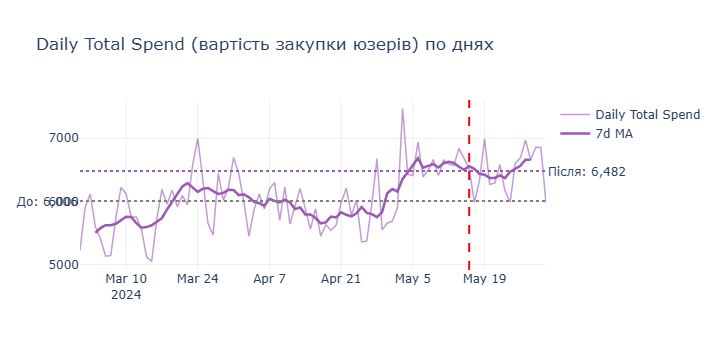


Кореляція daily_total_spend з revenue: -0.0171


In [136]:
# Мержимо spend з daily_features
daily_features = daily_features.merge(daily_spend, on='date', how='left')

# Порівняння до/після
pre_spend  = daily_features[daily_features['date'] < cutoff]['daily_total_spend'].mean()
post_spend = daily_features[daily_features['date'] >= cutoff]['daily_total_spend'].mean()

print(f"Daily total spend до збою:    {pre_spend:,.0f}")
print(f"Daily total spend після збою: {post_spend:,.0f}")
print(f"Δ spend: {post_spend-pre_spend:,.0f} ({(post_spend/pre_spend-1)*100:.1f}%)")

# Графік daily_total_spend по днях
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_features['date'],
    y=daily_features['daily_total_spend'],
    name='Daily Total Spend',
    line=dict(color='#9B59B6', width=1.5),
    opacity=0.6
))
fig.add_trace(go.Scatter(
    x=daily_features['date'],
    y=daily_features['daily_total_spend'].rolling(7, center=True).mean(),
    name='7d MA',
    line=dict(color='#9B59B6', width=2.5)
))

fig.add_vline(x='2024-05-16', line_dash='dash', line_color='red', line_width=2)
fig.add_hline(y=pre_spend,  line_dash='dot', line_color='grey',
              annotation_text=f'До: {pre_spend:,.0f}',
              annotation_position='left')
fig.add_hline(y=post_spend, line_dash='dot', line_color='#9B59B6',
              annotation_text=f'Після: {post_spend:,.0f}',
              annotation_position='right')

fig.update_layout(
    title='Daily Total Spend (вартість закупки юзерів) по днях',
    height=350,
    template='plotly_white'
)
fig.show()

# Кореляція spend з revenue
corr_spend = daily_features[['daily_total_spend','revenue']].corr()
print(f"\nКореляція daily_total_spend з revenue: {corr_spend.loc['daily_total_spend','revenue']:.4f}")

## Крок 8 — Атрибуція дропу виручки по факторах

**Мета:**
Розкласти загальні втрати виручки на складові —
скільки відсотків дропу пояснюється кожним фактором.

**Підхід — Counterfactual підстановка:**
Беремо фінальну модель (Ridge a=0.1).
Для кожної фічі окремо замінюємо пост-outage значення
на пре-outage середнє і дивимось як змінюється прогноз.
Різниця = внесок цього фактору у втрати.

**Фактори які аналізуємо:**
- Падіння conversion (fail_rate зріс на 4.2pp)
- Відтік чоловіків (share_male впав на 7.7pp)
- Зміна кількості унікальних юзерів
- Зміна кількості спроб оплат (attempts)
- Зміна частки split group 1
- Зміна частки US юзерів

Прогноз (baseline): 133,055
Факт:               122,089
Загальні втрати:    10,967

=== Атрибуція дропу по факторах ===
Фіча                         Pre avg   Post avg          Δ    Ефект $    % дропу
--------------------------------------------------------------------------------
unique_users                1852.724   1720.562   -132.161      9,294      84.7%
t                             37.500     83.500     46.000      6,298      57.4%
share_male                     0.428      0.350     -0.077        940       8.6%
share_female                   0.572      0.650      0.077        820       7.5%
is_post_os                     0.408      1.000      0.592        410       3.7%
share_us                       0.476      0.471     -0.005        186       1.7%
share_65plus                   0.302      0.299     -0.003        132       1.2%
week_of_month                  2.487      3.812      1.326       -918      -8.4%
is_post_support                0.605      1.000      0.395       -998 

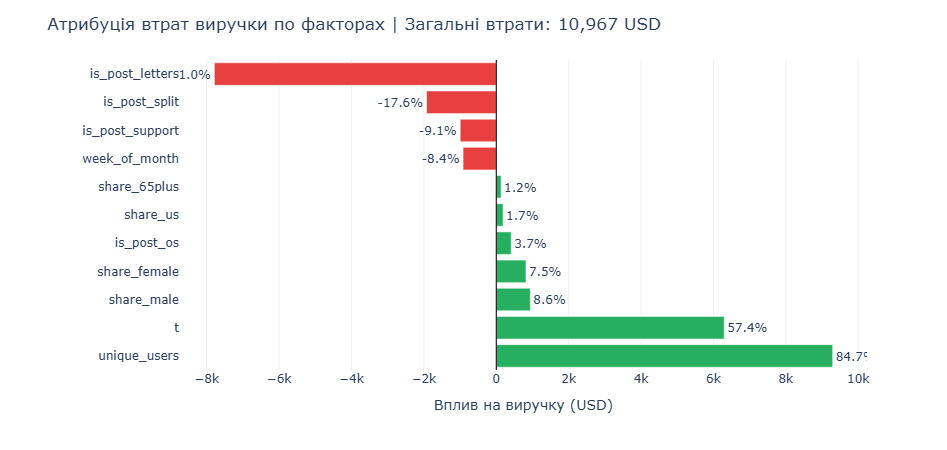

In [137]:
# === КРОК 8: Атрибуція дропу ===

# Фінальна модель вже натренована — Ridge a=0.1
# Беремо test період (May 16-31)

train = daily_features[daily_features['date'] < cutoff].copy()
test  = daily_features[daily_features['date'] >= cutoff].copy()

y_test = test['revenue']

# Базовий прогноз (з реальними пост-outage фічами)
X_test_scaled = scaler_final.transform(test[feature_cols_ext])
baseline_pred = ridge_final.predict(X_test_scaled).sum()
actual = y_test.sum()
total_loss = baseline_pred - actual

print(f"Прогноз (baseline): {baseline_pred:,.0f}")
print(f"Факт:               {actual:,.0f}")
print(f"Загальні втрати:    {total_loss:,.0f}")

# Counterfactual — pre-outage середні по кожній фічі
pre_avg = train[feature_cols_ext].mean()

attribution = []

for feat in feature_cols_ext:
    # Замінюємо одну фічу на pre-outage середнє
    test_cf = test[feature_cols_ext].copy()
    test_cf[feat] = pre_avg[feat]
    
    X_cf = scaler_final.transform(test_cf)
    pred_cf = ridge_final.predict(X_cf).sum()
    
    # Ефект = наскільки виріс прогноз якби ця фіча була нормальною
    effect = pred_cf - baseline_pred
    
    attribution.append({
        'feature': feat,
        'effect': effect,
        'pre_avg': pre_avg[feat],
        'post_avg': test[feat].mean(),
        'delta': test[feat].mean() - pre_avg[feat]
    })

attr_df = pd.DataFrame(attribution)
attr_df['effect_pct'] = attr_df['effect'] / total_loss * 100
attr_df = attr_df.sort_values('effect', ascending=False)

# Тільки значущі фактори (|effect| > 100)
significant = attr_df[attr_df['effect'].abs() > 100]

print("\n=== Атрибуція дропу по факторах ===")
print(f"{'Фіча':<25} {'Pre avg':>10} {'Post avg':>10} {'Δ':>10} {'Ефект $':>10} {'% дропу':>10}")
print("-" * 80)
for _, row in significant.iterrows():
    print(f"{row['feature']:<25} {row['pre_avg']:>10.3f} {row['post_avg']:>10.3f} "
          f"{row['delta']:>10.3f} {row['effect']:>10,.0f} {row['effect_pct']:>9.1f}%")

# Графік
fig = go.Figure(go.Bar(
    x=significant['effect'],
    y=significant['feature'],
    orientation='h',
    marker_color=['#27AE60' if x > 0 else '#E84040' for x in significant['effect']],
    text=[f"{v:.1f}%" for v in significant['effect_pct']],
    textposition='outside'
))

fig.add_vline(x=0, line_color='black', line_width=1)

fig.update_layout(
    title=f'Атрибуція втрат виручки по факторах | Загальні втрати: {total_loss:,.0f} USD',
    height=450,
    template='plotly_white',
    xaxis_title='Вплив на виручку (USD)',
    margin=dict(l=180, t=60)
)
fig.show()

In [138]:
print(feature_cols_ext)

['t', 'dow', 'is_weekend', 'week_of_month', 'share_male', 'share_female', 'share_65plus', 'share_split1', 'share_ppc', 'share_us', 'attempts', 'unique_users', 'is_post_split', 'is_post_support', 'is_post_letters', 'is_post_os']


In [139]:
print("scaler_final:", 'scaler_final' in dir())
print("ridge_final:", 'ridge_final' in dir())
print("feature_cols_ext:", 'feature_cols_ext' in dir())
print("daily_features shape:", daily_features.shape)
print("cutoff:", cutoff)

scaler_final: True
ridge_final: True
feature_cols_ext: True
daily_features shape: (92, 22)
cutoff: 2024-05-16 00:00:00


=== Атрибуція по змінних фічах ===
Фіча                  Pre avg Post avg        Δ   Ефект $   % дропу
--------------------------------------------------------------------
unique_users         1852.724 1720.562 -132.161     9,294     84.7%
share_male              0.428    0.350   -0.077       940      8.6%
share_female            0.572    0.650    0.077       820      7.5%
share_us                0.476    0.471   -0.005       186      1.7%
share_65plus            0.302    0.299   -0.003       132      1.2%
attempts             2910.711 2890.750  -19.961        41      0.4%
share_split1            0.501    0.505    0.004        40      0.4%
share_ppc               0.464    0.467    0.002       -15     -0.1%

Пояснені втрати:        11,439 (104.3%)
Непояснений залишок:      -472 (-4.3%) ← чистий ефект збою


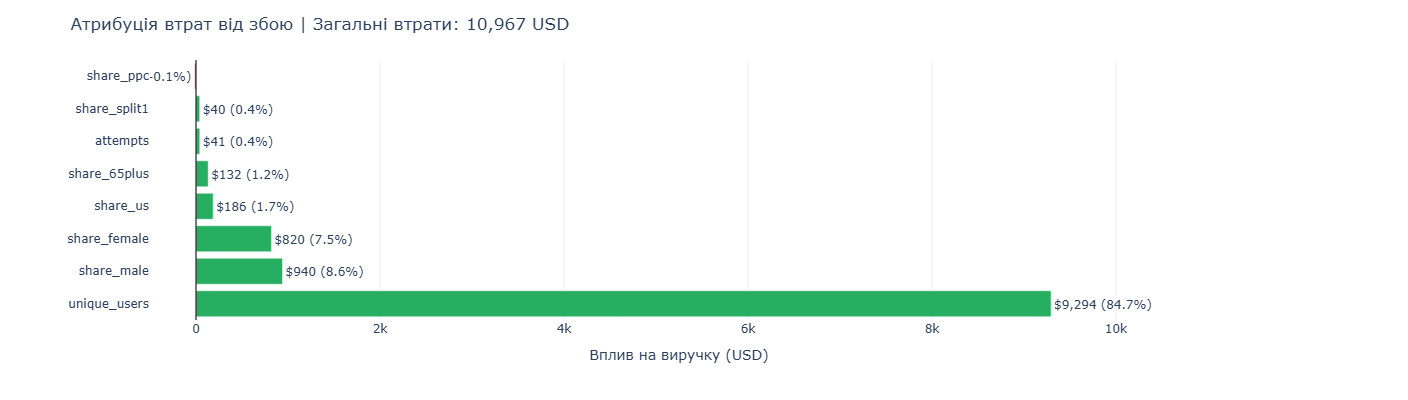

In [155]:


# Атрибуція тільки по фічах які реально змінились після збою
# Виключаємо бінарні події (вони вже були активні до збою)
exclude = ['is_post_split','is_post_support','is_post_letters','is_post_os','t','dow','is_weekend','week_of_month']

attribution_clean = []

for feat in feature_cols_ext:
    if feat in exclude:
        continue
    
    test_cf = test[feature_cols_ext].copy()
    test_cf[feat] = pre_avg[feat]
    
    X_cf = scaler_final.transform(test_cf)
    pred_cf = ridge_final.predict(X_cf).sum()
    effect = pred_cf - baseline_pred
    
    attribution_clean.append({
        'feature': feat,
        'effect': effect,
        'pre_avg': pre_avg[feat],
        'post_avg': test[feat].mean(),
        'delta': test[feat].mean() - pre_avg[feat],
        'effect_pct': effect / total_loss * 100
    })

attr_clean = pd.DataFrame(attribution_clean).sort_values('effect', ascending=False)

print("=== Атрибуція по змінних фічах ===")
print(f"{'Фіча':<20} {'Pre avg':>8} {'Post avg':>8} {'Δ':>8} {'Ефект $':>9} {'% дропу':>9}")
print("-" * 68)
for _, row in attr_clean.iterrows():
    print(f"{row['feature']:<20} {row['pre_avg']:>8.3f} {row['post_avg']:>8.3f} "
          f"{row['delta']:>8.3f} {row['effect']:>9,.0f} {row['effect_pct']:>8.1f}%")

# Сума пояснених втрат
explained = attr_clean['effect'].sum()
unexplained = total_loss - explained
print(f"\nПояснені втрати:    {explained:>10,.0f} ({explained/total_loss*100:.1f}%)")
print(f"Непояснений залишок:{unexplained:>10,.0f} ({unexplained/total_loss*100:.1f}%) ← чистий ефект збою")

# Графік
fig = go.Figure(go.Bar(
    x=attr_clean['effect'],
    y=attr_clean['feature'],
    orientation='h',
    marker_color=['#27AE60' if x > 0 else '#E84040' for x in attr_clean['effect']],
    text=[f"${v:,.0f} ({p:.1f}%)" for v, p in zip(attr_clean['effect'], attr_clean['effect_pct'])],
    textposition='outside'
))

fig.add_vline(x=0, line_color='black', line_width=1)
fig.update_layout(
    title=f'Атрибуція втрат від збою | Загальні втрати: {total_loss:,.0f} USD',
    height=400,
    template='plotly_white',
    xaxis_title='Вплив на виручку (USD)',
    xaxis_range=[-500, 11000],
    margin=dict(l=150, t=60, r=200)
)
fig.show()

## Крок 9 — Поведінка спліт-груп до/після збою

**Мета:**
Перевірити чи вплинув збій однаково на контрольну (0) і тестову (1) групи.
Якщо lift між групами зберігся — результати спліт-тесту валідні попри збій.

**Що аналізуємо:**
- Conversion rate по групах до/після
- ARPU по групах до/після
- Lift тестової групи над контрольною до/після
- Денна виручка по групах

=== ARPU по split групах ===
Період                                ARPU_0   ARPU_1     Lift
--------------------------------------------------------------
До спліту (Mar1-14)                     4.17     4.16    -0.4%
Спліт активний (Mar15-May15)            4.47     5.19    16.1%
Після збою (May16-31)                   4.12     4.75    15.4%


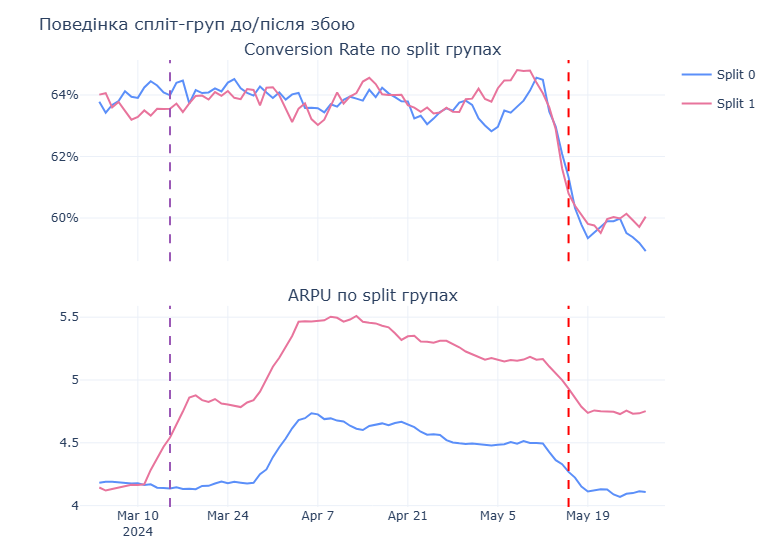

In [143]:
# Фікс типу split_group
p_ok['split_group'] = p_ok['split_group'].astype(str)
p['split_group'] = p['split_group'].astype(str)

# ARPU по split групах по днях
split_arpu = p_ok.groupby(['date','split_group']).agg(
    revenue=('amount_original','sum'),
    users=('id_user','nunique')
).reset_index()
split_arpu['arpu'] = split_arpu['revenue'] / split_arpu['users']
split_arpu['date'] = pd.to_datetime(split_arpu['date'])

print("=== ARPU по split групах ===")
print(f"{'Період':<35} {'ARPU_0':>8} {'ARPU_1':>8} {'Lift':>8}")
print("-" * 62)
for label, start, end in periods:
    sub = split_arpu[
        (split_arpu['date'] >= start) &
        (split_arpu['date'] < end)
    ]
    a0 = sub[sub['split_group']=='0']['arpu'].mean()
    a1 = sub[sub['split_group']=='1']['arpu'].mean()
    lift = (a1/a0 - 1) * 100
    print(f"{label:<35} {a0:>8.2f} {a1:>8.2f} {lift:>7.1f}%")

# Графік ARPU окремо
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Conversion Rate по split групах','ARPU по split групах'],
    shared_xaxes=True,
    vertical_spacing=0.10
)

colors = {'0': '#5B8FF9', '1': '#E8749C'}

for grp in ['0','1']:
    sub_conv = split_conv[split_conv['split_group']==int(grp)].sort_values('date')
    sub_arpu = split_arpu[split_arpu['split_group']==grp].sort_values('date')

    fig.add_trace(go.Scatter(
        x=sub_conv['date'],
        y=sub_conv['conversion'].rolling(7, center=True).mean(),
        name=f'Split {grp}',
        line=dict(color=colors[grp], width=2),
        legendgroup=f'split{grp}'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=sub_arpu['date'],
        y=sub_arpu['arpu'].rolling(7, center=True).mean(),
        name=f'Split {grp}',
        line=dict(color=colors[grp], width=2),
        legendgroup=f'split{grp}',
        showlegend=False
    ), row=2, col=1)

for date, color in [('2024-03-15','#9B59B6'),('2024-05-16','red')]:
    fig.add_vline(x=date, line_dash='dash', line_color=color, line_width=2)

fig.update_yaxes(tickformat='.0%', row=1, col=1)
fig.update_layout(
    height=550,
    template='plotly_white',
    title='Поведінка спліт-груп до/після збою',
    margin=dict(t=60, b=40)
)
fig.show()

In [157]:
from scipy import stats

periods = [
    ('До збою (Mar15-May15)', '2024-03-15', '2024-05-16'),
    ('Після збою (May16-31)', '2024-05-16', '2024-06-01'),
]

print("=== T-test + Mann-Whitney: Split 0 vs Split 1 по періодах ===\n")

for label, start, end in periods:
    # Юзери в цьому періоді
    users_in_period = p_ok[
        (p_ok['date'] >= start) & (p_ok['date'] < end)
    ]['id_user'].unique()

    # ARPU по групах для цих юзерів
    period_arpu = arpu_full[arpu_full['id_user'].isin(users_in_period)]
    
    g0 = period_arpu[period_arpu['split_group']=='0']['amount_original']
    g1 = period_arpu[period_arpu['split_group']=='1']['amount_original']

    # T-test
    t_stat, p_ttest = stats.ttest_ind(g0, g1)
    # Mann-Whitney
    u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    
    lift = (g1.median() / g0.median() - 1) * 100

    print(f"{label}")
    print(f"  n0={len(g0)}, n1={len(g1)}")
    print(f"  Median ARPU_0={g0.median():.2f} | ARPU_1={g1.median():.2f} | Lift={lift:.1f}%")
    print(f"  T-test p-value:       {p_ttest:.4f} | {'✅ Значимо' if p_ttest < 0.05 else '❌ Не значимо'}")
    print(f"  Mann-Whitney p-value: {p_mw:.4f} | {'✅ Значимо' if p_mw < 0.05 else '❌ Не значимо'}")
    print()

=== T-test + Mann-Whitney: Split 0 vs Split 1 по періодах ===

До збою (Mar15-May15)
  n0=47715, n1=47801
  Median ARPU_0=5.05 | ARPU_1=5.86 | Lift=16.0%
  T-test p-value:       0.0000 | ✅ Значимо
  Mann-Whitney p-value: 0.0000 | ✅ Значимо

Після збою (May16-31)
  n0=13014, n1=13250
  Median ARPU_0=5.36 | ARPU_1=6.10 | Lift=13.9%
  T-test p-value:       0.0000 | ✅ Значимо
  Mann-Whitney p-value: 0.0000 | ✅ Значимо



In [158]:
# Чи змінився fail rate після скорочення підтримки
support_date = '2024-03-31'

pre_support = daily_features[daily_features['date'] < support_date]['fail_rate'].mean()
post_support = daily_features[
    (daily_features['date'] >= support_date) & 
    (daily_features['date'] < '2024-05-16')
]['fail_rate'].mean()

print(f"Fail rate до скорочення підтримки:    {pre_support:.4f}")
print(f"Fail rate після скорочення підтримки: {post_support:.4f}")
print(f"Δ: {post_support - pre_support:.4f}")

# Чи змінилась виручка
pre_rev = daily_features[daily_features['date'] < support_date]['revenue'].mean()
post_rev = daily_features[
    (daily_features['date'] >= support_date) & 
    (daily_features['date'] < '2024-05-16')
]['revenue'].mean()
print(f"\nВиручка до:    {pre_rev:.0f}")
print(f"Виручка після: {post_rev:.0f}")
print(f"Δ: {post_rev - pre_rev:.0f} ({(post_rev/pre_rev-1)*100:.1f}%)")

Fail rate до скорочення підтримки:    0.3604
Fail rate після скорочення підтримки: 0.3622
Δ: 0.0017

Виручка до:    8058
Виручка після: 9152
Δ: 1094 (13.6%)


In [160]:
# Знаходимо точку зламу конверсії
# Беремо з daily де є conversion
baseline_conv = daily[
    (daily['date'] >= '2024-04-15') & 
    (daily['date'] < '2024-05-10')
]['conversion'].mean()

baseline_std = daily[
    (daily['date'] >= '2024-04-15') & 
    (daily['date'] < '2024-05-10')
]['conversion'].std()

print(f"Базова conversion (Apr15-May10): {baseline_conv:.4f}")
print(f"Std: {baseline_std:.4f}")
print(f"Поріг аномалії (mean - 2std): {baseline_conv - 2*baseline_std:.4f}")

# Травень по днях
may_data = daily[
    (daily['date'] >= '2024-05-01') & 
    (daily['date'] <= '2024-05-20')
][['date','conversion','revenue']].copy()

may_data['is_anomaly'] = may_data['conversion'] < (baseline_conv - 2*baseline_std)

print("\n=== Травень по днях ===")
print(f"{'Дата':<12} {'Conversion':>12} {'Revenue':>10} {'Аномалія':>10}")
print("-" * 48)
for _, row in may_data.iterrows():
    flag = '🔴' if row['is_anomaly'] else ''
    print(f"{str(row['date'].date()):<12} {row['conversion']:>12.4f} {row['revenue']:>10.0f} {flag:>5}")

Базова conversion (Apr15-May10): 0.6375
Std: 0.0084
Поріг аномалії (mean - 2std): 0.6207

=== Травень по днях ===
Дата           Conversion    Revenue   Аномалія
------------------------------------------------
2024-05-01         0.6240       8628      
2024-05-02         0.6334       8989      
2024-05-03         0.6479       8660      
2024-05-04         0.6326       8721      
2024-05-05         0.6340       8926      
2024-05-06         0.6280       8229      
2024-05-07         0.6301       9336      
2024-05-08         0.6446       9392      
2024-05-09         0.6609      10192      
2024-05-10         0.6456       8254      
2024-05-11         0.6504      10015      
2024-05-12         0.6407       8655      
2024-05-13         0.6396       8971      
2024-05-14         0.6312       8476      
2024-05-15         0.6301       8464      
2024-05-16         0.6085       7795     🔴
2024-05-17         0.6040       8114     🔴
2024-05-18         0.5747       8170     🔴
2024-05-19     

In [162]:
# Додаємо dow в daily
daily['dow'] = daily['date'].dt.dayofweek

dow_revenue = daily[daily['date'] < '2024-05-16'].groupby('dow')['revenue'].mean()
dow_revenue.index = ['Пн','Вт','Ср','Чт','Пт','Сб','Нд']

print("=== Середня виручка по днях тижня ===")
print(dow_revenue.round(0))
print(f"\nМакс: {dow_revenue.max():.0f}")
print(f"Мін:  {dow_revenue.min():.0f}")
print(f"Різниця макс/мін: {(dow_revenue.max()/dow_revenue.min()-1)*100:.1f}%")

=== Середня виручка по днях тижня ===
Пн    8588.0
Вт    8562.0
Ср    8412.0
Чт    8766.0
Пт    8636.0
Сб    9051.0
Нд    9031.0
Name: revenue, dtype: float64

Макс: 9051
Мін:  8412
Різниця макс/мін: 7.6%


In [163]:
# Виручка по кожному периоду
periods_rev = [
    ('До спліту (Mar1-14)',      '2024-03-01', '2024-03-15'),
    ('Спліт (Mar15-Mar31)',      '2024-03-15', '2024-04-01'),
    ('Після листів (Apr1-15)',   '2024-04-01', '2024-04-15'),
    ('Після OS (Apr15-May15)',   '2024-04-15', '2024-05-16'),
    ('Після збою (May16-31)',    '2024-05-16', '2024-06-01'),
]

print("=== Середня виручка по подіях ===")
for label, start, end in periods_rev:
    rev = daily[(daily['date'] >= start) & (daily['date'] < end)]['revenue'].mean()
    print(f"{label:<35} {rev:>8,.0f} USD/день")

=== Середня виручка по подіях ===
До спліту (Mar1-14)                    7,582 USD/день
Спліт (Mar15-Mar31)                    8,455 USD/день
Після листів (Apr1-15)                 9,112 USD/день
Після OS (Apr15-May15)                 9,203 USD/день
Після збою (May16-31)                  7,631 USD/день
